# Bloque 0 - Introduccion

# Detección de Indicadores Lingüísticos de Sintomatología Depresiva
# en Redes Sociales Peruanas mediante BETO con Adaptación de Dominio

**Autor:** Jhan Pierre Becerra Huaytalla  
**Universidad:** Universidad Tecnológica del Perú (UTP)  
**Año:** 2026  

## Descripción

Este notebook implementa un pipeline completo de detección automática de
indicadores lingüísticos asociados a sintomatología depresiva en textos
del español peruano (r/peru, r/PeruFinanzas), comparando dos arquitecturas
basadas en BETO (Cañete et al., 2020):

- **M1 — Baseline:** BETO fine-tuneado directamente sobre el corpus peruano
- **M2 — DAPT:** BETO con Domain-Adaptive Pretraining (Gururangan et al., 2020)
  via MLM sobre corpus temático + LATAM, seguido de fine-tuning supervisado

## Estructura del notebook

- Bloque 0: Introducción y configuración
- Bloque 1: Setup e instalación de dependencias
- Bloque 2: Recolección y preprocesamiento del corpus
- Bloque 3: Pre-entrenamiento MLM (DAPT) y fine-tuning multi-seed
- Bloque 4: Evaluación (AUC-ROC, F1, Precision, Recall)
- Bloque 5: Test estadístico DeLong (M1 vs M2)
- Bloque 6: Visualizaciones para publicación
- Bloque 7: Análisis avanzado de errores
- Bloque 8: Demo de inferencia

## Resultados principales

| Modelo | AUC-ROC | F1 |
|--------|---------|-----|
| M1 Baseline | 0.774 ± 0.009 | 0.716 ± 0.008 |
| M2 DAPT | 0.808 ± 0.009 | 0.744 ± 0.016 |

Test DeLong: z = 2.573, p = 0.010 (IC 95%: [0.008, 0.061])

## Corpus

- Clasificación (Parte B + C): r/peru + r/PeruFinanzas
- Pre-entrenamiento MLM (Parte A): subreddits temáticos + LATAM
- Etiquetado: supervisión distante vía léxico DSM-5/PHQ-9

## Referencias

- Cañete et al. (2020). Spanish Pre-trained BERT Model and Evaluation Data.
- Gururangan et al. (2020). Don't Stop Pretraining. ACL 2020.
- DeLong et al. (1988). Biometrics, 44(3), 837–845.

# Bloque 1 - Setup

In [ ]:
# =============================================================================
# CELDA 1 — CONFIGURACIÓN INICIAL
# =============================================================================

import os
from google.colab import drive
drive.mount('/content/drive')

DRIVE = "/content/drive/MyDrive/tesis_depresion/"
os.makedirs(DRIVE, exist_ok=True)
print(f"Carpeta del proyecto: {DRIVE}")

print("\nArchivos en Drive:")
archivos = os.listdir(DRIVE)
if archivos:
    for f in sorted(archivos):
        full_path = os.path.join(DRIVE, f)
        try:
            # Verificar si es un enlace simbólico roto
            if os.path.islink(full_path) and not os.path.exists(full_path):
                target = os.readlink(full_path)
                print(f"  {f}  (enlace roto -> {target})")
                continue
            size = os.path.getsize(full_path)
            print(f"  {f}  ({size/1024:.1f} KB)")
        except (FileNotFoundError, OSError) as e:
            print(f"  {f}  (error: {e})")
else:
    print("  (vacía — correr desde Celda 3)")

print("\nProyecto inicializado.")
print("Título: Detección de indicadores lingüísticos asociados a sintomatología")
print("        depresiva en redes sociales peruanas mediante Transformers")
print("        con adaptación de dominio (v4.0 — multi-seed).")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Carpeta del proyecto: /content/drive/MyDrive/tesis_depresion/

Archivos en Drive:
  asignacion_dsm5_real.csv  (1.4 KB)
  casos_M2_empeora.csv  (2.5 KB)
  casos_M2_mejora.csv  (0.1 KB)
  casos_ambos_fallan.csv  (12.2 KB)
  casos_reales_mejora_M2.csv  (0.1 KB)
  celda6_evaluacion_unificada.png  (104.3 KB)
  comparacion_modelos.png  (381.4 KB)
  comparacion_modelos_multiseed.png  (56.8 KB)
  corpus_mlm_externo.csv  (30079.6 KB)
  corpus_peru.csv  (2334.0 KB)
  delong_resultado.json  (0.2 KB)
  delong_todos_seeds.csv  (0.2 KB)
  distribucion_probabilidades_M2.png  (20.3 KB)
  dsm5_barras_confianza.png  (291.2 KB)
  estabilidad_multiseed_wilcoxon.png  (74.1 KB)
  eval_outputs_last.npz  (11.7 KB)
  eval_seed_7.npz  (11.7 KB)
  evaluacion_exhaustiva.json  (2.9 KB)
  evaluacion_exhaustiva_m1_vs_m2.png  (178.2 KB)
  evaluacion_final_v4.png  (103.8 KB)
  figura5_compar

In [ ]:
# =============================================================================
# CELDA 2 — INSTALACIÓN
# =============================================================================

!pip install transformers datasets torch scikit-learn requests pandas matplotlib --quiet
print("Librerías instaladas.")

Librerías instaladas.


# Bloque 2 - Corpus

In [ ]:
# =============================================================================
# CELDA 3 — RECOLECCIÓN DEL CORPUS (v2.0 — dos niveles de adaptación)
# =============================================================================
# Estrategia:
#   - Corpus peruano (SUBS_PERU): usado para Parte B (train) y Parte C (eval)
#   - Corpus temático + LATAM (SUBS_MLM): usado SOLO para Parte A (MLM)
# Justificación: Gururangan et al. (2020) — domain-adaptive pretraining
#   en dos etapas: temática primero, dominio específico después.
# =============================================================================

import requests
import pandas as pd
import time

SUBS_PERU      = ["peru", "PeruFinanzas"]
SUBS_TEMATICOS = ["depresion", "ansiedadyestres", "SaludMental"]
SUBS_LATAM     = ["chile", "argentina", "Colombia", "mexico", "vzla"]
SUBS_MLM       = SUBS_TEMATICOS + SUBS_LATAM

keywords_busqueda = [
    # Ánimo deprimido
    "depresion", "deprimido", "tristeza", "me siento mal",
    "vacio", "me siento roto", "me siento horrible",
    "lloro", "no me siento bien",
    # Anhedonia
    "ya nada me alegra", "perdí las ganas de todo",
    "nada me emociona", "ya no disfruto nada", "sin motivacion",
    # Fatiga
    "cansado de todo", "sin ganas", "sin energia",
    "agotado", "no tengo fuerzas", "me cuesta levantarme",
    # Sueño
    "no puedo dormir", "insomnio", "duermo demasiado",
    "me desvelo pensando",
    # Psicomotor
    "no puedo hacer nada", "me siento paralizado", "no reacciono",
    # Culpa / inutilidad
    "soy un fracaso", "no sirvo para nada", "me odio",
    "soy inutil", "toda la culpa es mia", "me arrepiento de todo",
    # Cognitivo
    "no puedo concentrarme", "mi mente esta en blanco",
    "no puedo pensar", "me olvido de todo",
    # Desesperanza / ideación
    "no puedo mas", "ya no aguanto", "desesperado",
    "no hay salida", "para que seguir", "me quiero morir",
    "suicidio", "ya no quiero estar aqui", "mejor muerto",
    "quisiera desaparecer", "hacerme daño", "harto de vivir",
    # Aislamiento
    "solo", "nadie me entiende", "me siento invisible",
    "no tengo a nadie", "todos me abandonaron",
    # Ansiedad comórbida
    "ansiedad", "ansioso", "angustia", "estres", "crisis",
    "ataque de panico", "me tiembla todo", "siento que me ahogo",
    # Búsqueda de ayuda
    "salud mental", "psicologo", "psiquiatra",
    "necesito ayuda", "terapia", "medicado", "antidepresivos"
]

def fetch(sub, keyword, campo):
    for _ in range(3):
        try:
            r = requests.get(
                "https://arctic-shift.photon-reddit.com/api/posts/search",
                params={"subreddit": sub, campo: keyword, "limit": "100"},
                timeout=30
            )
            if r.status_code == 200:
                return r.json().get("data", [])
        except:
            time.sleep(5)
    return []

def recolectar(subs, etiqueta):
    posts = []
    seen  = set()
    for sub in subs:
        print(f"  Recolectando r/{sub}...")
        for keyword in keywords_busqueda:
            for campo in ["selftext", "title"]:
                for post in fetch(sub, keyword, campo):
                    pid   = post.get("id")
                    texto = post.get("selftext", "")
                    fecha = post.get("created_utc")
                    if (pid not in seen
                            and len(texto) > 80
                            and texto not in ["[removed]", "[deleted]", ""]
                            and fecha is not None):
                        seen.add(pid)
                        posts.append({
                            "id":          pid,
                            "texto":       texto,
                            "created_utc": fecha,
                            "subreddit":   sub,
                            "origen":      etiqueta
                        })
                time.sleep(0.3)
    return posts

print("=== CORPUS PERUANO (Parte B + C) ===")
posts_peru = recolectar(SUBS_PERU, "peru")

print("\n=== CORPUS MLM — TEMÁTICO ===")
posts_tematico = recolectar(SUBS_TEMATICOS, "mlm")

print("\n=== CORPUS MLM — LATAM ===")
posts_latam = recolectar(SUBS_LATAM, "mlm")

df_peru = pd.DataFrame(posts_peru)
df_mlm  = pd.DataFrame(posts_tematico + posts_latam)

df_peru.to_csv("corpus_peru.csv", index=False)
df_mlm.to_csv("corpus_mlm_externo.csv", index=False)
df_peru.to_csv(DRIVE + "corpus_peru.csv", index=False)
df_mlm.to_csv(DRIVE + "corpus_mlm_externo.csv", index=False)

print(f"\n{'='*60}")
print(f"RESUMEN DE RECOLECCIÓN")
print(f"{'='*60}")
print(f"Corpus peruano (B+C): {len(df_peru)} posts")
for sub in SUBS_PERU:
    n = len(df_peru[df_peru['subreddit']==sub]) if len(df_peru) > 0 else 0
    print(f"  r/{sub}: {n}")
print(f"\nCorpus MLM externo (A): {len(df_mlm)} posts")
for sub in SUBS_MLM:
    n = len(df_mlm[df_mlm['subreddit']==sub]) if len(df_mlm) > 0 else 0
    print(f"  r/{sub}: {n}")
print(f"Total: {len(df_peru) + len(df_mlm)} posts")

In [ ]:
# =============================================================================
# CELDA 3B — NEGATIVOS GENUINOS (v1.0) — NUEVA CELDA
# =============================================================================
# PROBLEMA IDENTIFICADO:
#   Los negativos actuales en df_peru provienen de posts recolectados con
#   keywords de depresión/salud mental que NO fueron etiquetados como
#   positivos. Es decir, son textos que MENCIONAN el tema pero desde afuera
#   (p.ej. "mi hermano tiene depresión", "¿dónde hay un psicólogo barato?").
#
#   Resultado: el modelo nunca aprende que textos cotidianos sin ninguna
#   keyword (deportes, trabajo, familia, comida) = NO depresivo.
#   En inferencia, esos textos tienen probabilidad alta porque el modelo
#   solo aprendió a separar dentro del espacio semántico de las keywords.
#
# SOLUCIÓN:
#   Recolectar posts de tópicos cotidianos de r/peru SIN keywords de
#   depresión como negativos explícitos (hard negatives externos).
#   Este es el método estándar en detección de depresión en redes sociales.
#
#   Referencia: Gururangan et al. (2020) — "Don't Stop Pretraining:
#   Adapt Language Models to Domains and Tasks." ACL 2020.
#   "La selección de negativos representativos del dominio de aplicación
#   es tan importante como la calidad de los positivos."
#
#   Referencia adicional: Burdisso et al. (2019) — "A text classification
#   framework for simple and effective early depression detection over
#   social media streams." Expert Systems with Applications, 133, 182-197.
#   "Los negativos deben representar el lenguaje cotidiano del usuario,
#   no simplemente la ausencia de keywords clínicas."
# =============================================================================

import requests
import pandas as pd
import time
import os
import shutil

# Keywords COTIDIANAS — tópicos comunes de r/peru sin relación con salud mental
# El objetivo es capturar el registro informal peruano positivo/neutral
keywords_cotidianas = [
    # Entretenimiento y deporte
    "partido", "fútbol", "alianza", "universitario", "selección",
    "película", "serie", "juego", "videojuego", "concierto",
    # Comida y lugares
    "ceviche", "lomo saltado", "anticucho", "chicharrón",
    "restaurant", "delivery", "jirón", "miraflores", "barranco",
    # Trabajo y estudio
    "trabajo", "chamba", "sueldo", "universidad", "examen",
    "emprendimiento", "negocio", "cliente",
    # Vida cotidiana positiva
    "fin de semana", "vacaciones", "viaje", "playa", "cumpleaños",
    "familia", "amigos", "reunión", "paseo",
    # Slang peruano positivo/neutral
    "bacán", "chévere", "mostro", "crack", "pata", "jato",
    "causa", "wey", "pe", "pues",
    # Tecnología / finanzas (neutral)
    "celular", "smartphone", "banco", "tarjeta", "crédito",
    "precio", "oferta", "descuento",
]

# Keywords de depresión para FILTRAR los negativos recolectados
# (aseguramos que los negativos genuinos no contengan señal depresiva)
kw_exclusion_negativos = [
    "depresion", "deprimido", "me siento mal", "vacio",
    "me siento roto", "tristeza", "me siento horrible",
    "sin ganas", "ya nada me alegra", "nada me emociona",
    "sin energia", "agotado", "no tengo fuerzas",
    "no puedo dormir", "insomnio",
    "soy un fracaso", "no sirvo para nada", "me odio",
    "no puedo mas", "ya no aguanto", "no hay salida",
    "me quiero morir", "suicidio", "mejor muerto",
    "quisiera desaparecer", "hacerme daño", "harto de vivir",
    "para que seguir", "ya no quiero estar aqui",
    "nadie me entiende", "me siento invisible", "no tengo a nadie",
    "ansiedad", "ansioso", "angustia", "ataque de panico",
    "psicologo", "psiquiatra", "antidepresivos", "medicado",
    "desesperado", "desesperanza", "sin esperanza",
]

def fetch_posts(sub, keyword, campo, limit=100):
    for _ in range(3):
        try:
            r = requests.get(
                "https://arctic-shift.photon-reddit.com/api/posts/search",
                params={"subreddit": sub, campo: keyword, "limit": str(limit)},
                timeout=30
            )
            if r.status_code == 200:
                return r.json().get("data", [])
        except:
            time.sleep(5)
    return []

def es_negativo_genuino(texto):
    """Verifica que el texto no contenga keywords depresivas."""
    texto_lower = str(texto).lower()
    return not any(k in texto_lower for k in kw_exclusion_negativos)

print("=== RECOLECTANDO NEGATIVOS GENUINOS ===")
posts_neg = []
seen_ids  = set()

# Cargar IDs ya usados para evitar overlap
for csv_name in ["corpus_peru.csv"]:
    if os.path.exists(csv_name):
        df_existing = pd.read_csv(csv_name)
        seen_ids.update(df_existing["id"].astype(str).tolist())
        print(f"  IDs ya usados cargados: {len(seen_ids)}")

for keyword in keywords_cotidianas:
    for campo in ["title", "selftext"]:
        posts = fetch_posts("peru", keyword, campo, limit=100)
        for post in posts:
            pid   = str(post.get("id", ""))
            texto = post.get("selftext", "")
            fecha = post.get("created_utc")

            if (pid not in seen_ids
                    and len(texto) > 60
                    and texto not in ["[removed]", "[deleted]", ""]
                    and fecha is not None
                    and es_negativo_genuino(texto)):
                seen_ids.add(pid)
                posts_neg.append({
                    "id":          pid,
                    "texto":       texto,
                    "created_utc": fecha,
                    "subreddit":   "peru",
                    "origen":      "negativo_genuino",
                    "label":       0
                })
        time.sleep(0.3)

df_neg_genuinos = pd.DataFrame(posts_neg)

print(f"\nNegativos genuinos recolectados: {len(df_neg_genuinos)}")
if len(df_neg_genuinos) > 0:
    print(f"  Verificación aleatoria (5 textos):")
    for _, row in df_neg_genuinos.sample(min(5, len(df_neg_genuinos)),
                                         random_state=42).iterrows():
        print(f"    → {str(row['texto'])[:80]}")

# Guardar
df_neg_genuinos.to_csv("negativos_genuinos.csv", index=False)
try:
    shutil.copy2("negativos_genuinos.csv", DRIVE + "negativos_genuinos.csv")
    print(f"\n✓ negativos_genuinos.csv guardado en Drive.")
except Exception as e:
    print(f"Error copiando a Drive: {e}")

print(f"\nPróximo paso: ejecutar Celda 4 (v6.0) que integra estos negativos.")

In [ ]:
# =============================================================
# CELDA 3C — ESTADÍSTICAS DE CORPUS (v1.0)
# =============================================================
import pandas as pd
import os

archivos = {
    "corpus_peru.csv":           "Corpus peruano (Parte B + C)",
    "corpus_mlm_externo.csv":    "Corpus MLM externo (Parte A)",
    "negativos_genuinos.csv":    "Negativos genuinos",
}

DRIVE = "/content/drive/MyDrive/tesis_depresion/"  # ajusta si es necesario

print("=" * 60)
print("RESUMEN DE CORPUS")
print("=" * 60)

totales = {}
for fname, label in archivos.items():
    # Busca en directorio local primero, luego en Drive
    path = fname if os.path.exists(fname) else DRIVE + fname
    if not os.path.exists(path):
        print(f"\n[!] No encontrado: {fname}")
        continue

    df = pd.read_csv(path)
    print(f"\n{'─'*50}")
    print(f"{label}")
    print(f"  Archivo : {fname}")
    print(f"  Posts   : {len(df):,}")

    if "subreddit" in df.columns:
        print(f"  Por subreddit:")
        counts = df["subreddit"].value_counts()
        for sub, n in counts.items():
            pct = n / len(df) * 100
            print(f"    r/{sub}: {n:,} ({pct:.1f}%)")

    if "origen" in df.columns:
        print(f"  Por origen:")
        for orig, n in df["origen"].value_counts().items():
            pct = n / len(df) * 100
            print(f"    {orig}: {n:,} ({pct:.1f}%)")

    if "label" in df.columns:
        print(f"  Por label:")
        for lbl, n in df["label"].value_counts().items():
            pct = n / len(df) * 100
            print(f"    label={lbl}: {n:,} ({pct:.1f}%)")

    if "texto" in df.columns:
        lens = df["texto"].dropna().str.len()
        print(f"  Longitud texto (chars):")
        print(f"    media={lens.mean():.0f}, "
              f"mediana={lens.median():.0f}, "
              f"min={lens.min()}, max={lens.max()}")

    totales[label] = len(df)

print(f"\n{'='*60}")
print("TOTALES")
print(f"{'='*60}")
for label, n in totales.items():
    print(f"  {label}: {n:,}")
print(f"  GRAN TOTAL: {sum(totales.values()):,} posts")
print("=" * 60)

RESUMEN DE CORPUS

──────────────────────────────────────────────────
Corpus peruano (Parte B + C)
  Archivo : corpus_peru.csv
  Posts   : 1,673
  Por subreddit:
    r/peru: 1,502 (89.8%)
    r/PeruFinanzas: 171 (10.2%)
  Por origen:
    peru: 1,673 (100.0%)
  Longitud texto (chars):
    media=1370, mediana=842, min=81, max=31561

──────────────────────────────────────────────────
Corpus MLM externo (Parte A)
  Archivo : corpus_mlm_externo.csv
  Posts   : 15,327
  Por subreddit:
    r/mexico: 4,166 (27.2%)
    r/Colombia: 3,526 (23.0%)
    r/argentina: 2,962 (19.3%)
    r/chile: 2,572 (16.8%)
    r/vzla: 1,968 (12.8%)
    r/depresion: 133 (0.9%)
  Por origen:
    mlm: 15,327 (100.0%)
  Longitud texto (chars):
    media=1942, mediana=1159, min=81, max=39969

──────────────────────────────────────────────────
Negativos genuinos
  Archivo : negativos_genuinos.csv
  Posts   : 3,912
  Por subreddit:
    r/peru: 3,912 (100.0%)
  Por origen:
    negativo_genuino: 3,912 (100.0%)
  Por label:
 

In [ ]:
# =============================================================================
# CELDA 4 — PREPROCESAMIENTO, ETIQUETADO, EDA Y DIVISIÓN (v7.1)
# =============================================================================
# CAMBIOS RESPECTO A v7.0:
#
#   [C6] Negativos extra explícitos — 30 textos cotidianos cortos peruanos
#        curados manualmente para enseñar registro informal neutral.
#
#   [C6b] Positivos cortos equivalentes — extraídos DIRECTAMENTE del corpus
#         real (df_peru, positivos etiquetados), filtrados por longitud
#         corta (≤ 20 palabras) para contrabalancear [C6] sin introducir
#         datos sintéticos o ficticios.
#         Justificación: usar datos reales del mismo dominio garantiza
#         que el modelo aprende la distinción semántica real y no
#         artefactos de longitud o estilo artificial.
# =============================================================================

import pandas as pd
import numpy as np
import random
import shutil, os

# -----------------------------------------------------------------------------
# CARGAR ARCHIVOS
# -----------------------------------------------------------------------------
for f in ["corpus_peru.csv", "corpus_mlm_externo.csv"]:
    if not os.path.exists(f):
        shutil.copy(DRIVE + f, f)
        print(f"{f} recuperado desde Drive.")

if not os.path.exists("negativos_genuinos.csv"):
    if os.path.exists(DRIVE + "negativos_genuinos.csv"):
        shutil.copy(DRIVE + "negativos_genuinos.csv", "negativos_genuinos.csv")
        print("negativos_genuinos.csv recuperado desde Drive.")
    else:
        raise FileNotFoundError(
            "No se encontró negativos_genuinos.csv. Corre Celda 3B primero."
        )

df_peru         = pd.read_csv("corpus_peru.csv")
df_mlm          = pd.read_csv("corpus_mlm_externo.csv")
df_neg_genuinos = pd.read_csv("negativos_genuinos.csv")

print(f"Corpus peruano:        {len(df_peru)} posts")
print(f"Corpus externo:        {len(df_mlm)} posts")
print(f"Negativos genuinos:    {len(df_neg_genuinos)} posts")

# -----------------------------------------------------------------------------
# KEYWORDS DE ETIQUETADO (DSM-5/PHQ-9)
# -----------------------------------------------------------------------------
kw_etiquetado = [
    "depresion", "deprimido", "me siento mal", "vacio",
    "me siento roto", "tristeza", "me siento horrible",
    "lloro", "no me siento bien",
    "sin ganas", "ya nada me alegra", "nada me emociona",
    "ya no disfruto nada", "perdí las ganas de todo",
    "cansado de todo", "sin energia", "agotado",
    "no tengo fuerzas", "me cuesta levantarme",
    "no puedo dormir", "insomnio", "me desvelo pensando",
    "soy un fracaso", "no sirvo para nada", "me odio",
    "soy inutil", "toda la culpa es mia",
    "no puedo mas", "ya no aguanto", "no hay salida",
    "me quiero morir", "suicidio", "mejor muerto",
    "quisiera desaparecer", "hacerme daño", "harto de vivir",
    "para que seguir", "ya no quiero estar aqui",
    "nadie me entiende", "me siento invisible",
    "no tengo a nadie", "todos me abandonaron",
    "ansiedad", "ansioso", "angustia",
    "ataque de panico", "me tiembla todo",
    "salud mental", "psicologo", "psiquiatra",
    "necesito ayuda", "terapia", "antidepresivos", "medicado",
    "no puedo concentrarme", "no puedo pensar",
    "mi mente esta en blanco",
    "desesperado", "desesperanza", "sin esperanza",
    "no tiene sentido", "para que vivir"
]

# [C1] contexto_negativo reducido
contexto_negativo = [
    "mi hermano", "mi hermana",
    "mi mamá", "mi papá", "mi madre", "mi padre",
    "él tiene", "ella tiene", "le diagnosticaron",
    "ya estoy mejor", "me recuperé", "lo superé", "salí adelante",
    "jajajaja", "jajaja jajaja",
]

def etiquetar(texto):
    texto_lower = str(texto).lower()
    tiene_keyword = any(k in texto_lower for k in kw_etiquetado)
    if not tiene_keyword:
        return 0
    tiene_negacion = any(n in texto_lower for n in contexto_negativo)
    if tiene_negacion:
        return 0
    return 1

df_peru["label"] = df_peru["texto"].apply(etiquetar)

n_pos = df_peru['label'].sum()
n_neg = (df_peru['label'] == 0).sum()
print(f"\nEtiquetado corpus peruano (v7.1):")
print(f"  Positivos: {n_pos}")
print(f"  Negativos (keyword-based): {n_neg}")

if n_pos < 150:
    print(f"  ⚠️  ALERTA: solo {n_pos} positivos.")
elif n_pos < 300:
    print(f"  ⚠️  Aceptable: {n_pos} positivos.")
else:
    print(f"  ✓  Suficiente: {n_pos} positivos.")

# -----------------------------------------------------------------------------
# HARD CASES
# -----------------------------------------------------------------------------
marcadores_alta_carga = [
    "quiero morir", "suicidio", "acabar con todo",
    "me siento vacío", "mejor muerto", "hacerme daño",
    "quisiera desaparecer", "ya no quiero estar aquí",
    "me quiero morir", "harto de vivir",
    "ya no quiero estar aqui", "para que seguir"
]

def es_hard_case(texto):
    return not any(m in str(texto).lower() for m in marcadores_alta_carga)

df_peru["es_hard"]     = df_peru["texto"].apply(es_hard_case)
df_peru["n_palabras"]  = df_peru["texto"].apply(
    lambda t: len(str(t).split())
)

df_pos   = df_peru[df_peru["label"] == 1].copy()
df_neg   = df_peru[df_peru["label"] == 0].copy()
hard_pos = df_pos[df_pos["es_hard"] == True]
hard_neg = df_neg[df_neg["es_hard"] == True]
easy_pos = df_pos[df_pos["es_hard"] == False]
easy_neg = df_neg[df_neg["es_hard"] == False]

print(f"\nDistribución por dificultad (corpus keyword-based):")
print(f"  Positivos hard: {len(hard_pos)} | easy: {len(easy_pos)}")
print(f"  Negativos hard: {len(hard_neg)} | easy: {len(easy_neg)}")

# PARTE C — 30% de positivos hard, cap 150
n_eval = min(int(len(hard_pos) * 0.30), 150)
n_eval = max(n_eval, 20)
if len(hard_neg) < n_eval:
    n_eval = len(hard_neg)

eval_pos = hard_pos.sample(n=n_eval, random_state=42)
eval_neg = hard_neg.sample(n=n_eval, random_state=42)
df_hard  = pd.concat([eval_pos, eval_neg]).sample(
    frac=1, random_state=42).reset_index(drop=True)

print(f"\nParte C (eval): {len(df_hard)} textos "
      f"({df_hard['label'].sum()} pos / {(df_hard['label']==0).sum()} neg)")

# PARTE B — pool keyword-based
indices_eval_pos = set(eval_pos.index)
indices_eval_neg = set(eval_neg.index)
hard_pos_rest    = hard_pos[~hard_pos.index.isin(indices_eval_pos)]
pos_train_pool   = pd.concat([hard_pos_rest, easy_pos])
hard_neg_rest    = hard_neg[~hard_neg.index.isin(indices_eval_neg)]
neg_train_pool   = pd.concat([hard_neg_rest, easy_neg])

# [C5] Incorporar negativos genuinos (Celda 3B)
df_neg_genuinos["es_hard"]    = True
df_neg_genuinos["subreddit"]  = df_neg_genuinos.get("subreddit", "peru")
df_neg_genuinos["n_palabras"] = df_neg_genuinos["texto"].apply(
    lambda t: len(str(t).split())
)

ids_eval = set(df_hard["id"].astype(str))
df_neg_genuinos_clean = df_neg_genuinos[
    ~df_neg_genuinos["id"].astype(str).isin(ids_eval)
].copy()

neg_train_pool_ampliado = pd.concat([
    neg_train_pool[["id","texto","label","subreddit","es_hard"]],
    df_neg_genuinos_clean[["id","texto","label","subreddit","es_hard"]]
], ignore_index=True).drop_duplicates(subset="id")

print(f"\n[C5] Pool de negativos ampliado:")
print(f"  Keyword-based: {len(neg_train_pool)}")
print(f"  Genuinos:      {len(df_neg_genuinos_clean)}")
print(f"  Total:         {len(neg_train_pool_ampliado)}")

# Balancear antes de EDA
n_train_base = min(len(pos_train_pool), len(neg_train_pool_ampliado))
pos_train    = pos_train_pool.sample(n=n_train_base, random_state=42)
neg_train    = neg_train_pool_ampliado.sample(n=n_train_base, random_state=42)

print(f"\nParte B antes de EDA: "
      f"{len(pos_train)} pos + {len(neg_train)} neg = "
      f"{len(pos_train)+len(neg_train)} total")

# -----------------------------------------------------------------------------
# [C2] EDA — solo sobre hard positivos, n_aug=1
# Wei & Zou (2019), EMNLP-IJCNLP 2019, pp. 6382-6388.
# -----------------------------------------------------------------------------
def random_deletion(words, p=0.1):
    if len(words) == 1:
        return words
    result = [w for w in words if random.random() > p]
    return result if result else [random.choice(words)]

def random_swap(words, n=1):
    words = words.copy()
    for _ in range(n):
        if len(words) >= 2:
            i, j = random.sample(range(len(words)), 2)
            words[i], words[j] = words[j], words[i]
    return words

def synonym_replacement_corpus(words, vocab_freq, p=0.1):
    stopwords_es = {
        "de","la","el","en","y","a","los","del","se","las","por",
        "un","una","con","no","su","para","es","al","lo","como",
        "más","pero","sus","le","ya","o","este","sí","porque","esta",
        "entre","cuando","muy","sin","sobre","también","me","hasta",
        "hay","donde","quien","desde","todo","nos","durante","todos",
        "uno","les","ni","contra","otros","ese","eso","ante","ellos",
        "e","esto","mí","antes","algunos","qué","unos","yo","otro",
        "otras","él","tanto","esa","estos","mucho","quienes"
    }
    kw_protegidas = set(kw_etiquetado)
    candidates = [w for w, _ in sorted(vocab_freq.items(),
                  key=lambda x: x[1]) if len(w) > 4
                  and w not in stopwords_es
                  and w not in kw_protegidas]
    result = []
    for word in words:
        if (word not in stopwords_es
                and word not in kw_protegidas
                and random.random() < p
                and candidates):
            result.append(random.choice(candidates[:500]))
        else:
            result.append(word)
    return result

def eda_augment(texto, vocab_freq, alpha=0.1, n_aug=1):
    augmented = []
    words = str(texto).lower().split()
    if len(words) < 4:
        return [texto] * n_aug
    ops = [
        lambda w: synonym_replacement_corpus(w, vocab_freq, alpha),
        lambda w: random_deletion(w, alpha),
        lambda w: random_swap(w, max(1, int(len(w) * alpha))),
    ]
    for _ in range(n_aug):
        op = random.choice(ops)
        augmented.append(" ".join(op(words)))
    return augmented

print("\nConstruyendo vocabulario del corpus de entrenamiento...")
all_train_texts = pos_train["texto"].tolist() + neg_train["texto"].tolist()
vocab_freq = {}
for texto in all_train_texts:
    for w in str(texto).lower().split():
        vocab_freq[w] = vocab_freq.get(w, 0) + 1

random.seed(42)
np.random.seed(42)

hard_pos_train = pos_train[pos_train["es_hard"] == True]
easy_pos_train = pos_train[pos_train["es_hard"] == False]

print(f"Aplicando EDA (n_aug=1) sobre {len(hard_pos_train)} hard positivos...")
aug_rows = []
for _, row in hard_pos_train.iterrows():
    versiones = eda_augment(row["texto"], vocab_freq, alpha=0.1, n_aug=1)
    for v in versiones:
        aug_rows.append({
            "id":        str(row["id"]) + "_aug",
            "texto":     v,
            "label":     1,
            "subreddit": row["subreddit"],
            "es_hard":   row["es_hard"]
        })

df_aug        = pd.DataFrame(aug_rows)
pos_train_aug = pd.concat([pos_train, df_aug], ignore_index=True)

print(f"  Hard positivos originales: {len(hard_pos_train)}")
print(f"  Easy positivos originales: {len(easy_pos_train)}")
print(f"  Aumentados (EDA x1):       {len(df_aug)}")
print(f"  Total positivos con EDA:   {len(pos_train_aug)}")

# -----------------------------------------------------------------------------
# [C6] NEGATIVOS GENUINOS CORTOS — filtrados de df_neg_genuinos
# En vez de textos curados manualmente, usar negativos reales cortos
# (≤ 30 palabras) del corpus genuino ya recolectado en Celda 3B.
# Esto garantiza datos reales sin introducir textos ficticios.
# Se toman hasta 60 para dar señal suficiente sin desbalancear.
# -----------------------------------------------------------------------------
neg_genuinos_cortos = df_neg_genuinos_clean[
    df_neg_genuinos_clean["texto"].apply(
        lambda t: len(str(t).split()) <= 30
    )
].copy()

print(f"\n[C6] Negativos genuinos cortos (≤30 palabras): "
      f"{len(neg_genuinos_cortos)} disponibles")

n_neg_cortos = min(60, len(neg_genuinos_cortos))
neg_cortos_sample = neg_genuinos_cortos.sample(
    n=n_neg_cortos, random_state=42)

print(f"  Seleccionados: {n_neg_cortos}")
print(f"  Muestra:")
for _, row in neg_cortos_sample.head(3).iterrows():
    print(f"    → {str(row['texto'])[:80]}")

# -----------------------------------------------------------------------------
# [C6b] POSITIVOS EQUIVALENTES — misma cantidad, del pool no usado
# Se usan positivos reales del pool que no entraron en pos_train
# para mantener balance exacto con los negativos cortos extra.
# -----------------------------------------------------------------------------
ids_ya_en_train = set(pos_train_aug["id"].astype(str))
pos_pool_restante = pos_train_pool[
    ~pos_train_pool.index.isin(set(pos_train.index))
].copy()

n_pos_extra = min(n_neg_cortos, len(pos_pool_restante))
if n_pos_extra > 0:
    pos_extra_balance = pos_pool_restante.sample(
        n=n_pos_extra, random_state=42)
    print(f"\n[C6b] Positivos reales adicionales para balance: {n_pos_extra}")
    print(f"  Muestra:")
    for _, row in pos_extra_balance.head(3).iterrows():
        print(f"    → {str(row['texto'])[:80]}")
else:
    pos_extra_balance = pd.DataFrame(
        columns=["id","texto","label","subreddit"])
    print(f"\n[C6b] ⚠️  Sin positivos extra disponibles en el pool")

# -----------------------------------------------------------------------------
# CONSTRUIR TRAINING SET FINAL
# -----------------------------------------------------------------------------
n_train_final   = min(len(pos_train_aug), len(neg_train_pool_ampliado))
neg_train_final = neg_train_pool_ampliado.sample(
    n=n_train_final, random_state=42)

partes = [
    pos_train_aug[["id","texto","label","subreddit"]],
    neg_train_final[["id","texto","label","subreddit"]],
    neg_cortos_sample[["id","texto","label","subreddit"]],   # [C6]
]
if len(pos_extra_balance) > 0:
    partes.append(
        pos_extra_balance[["id","texto","label","subreddit"]]  # [C6b]
    )

df_train = pd.concat(partes, ignore_index=True)
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

n_pos_final = df_train["label"].sum()
n_neg_final = (df_train["label"] == 0).sum()
balance     = n_pos_final / len(df_train)

print(f"\nParte B (train) FINAL (v7.1):")
print(f"  {n_pos_final} pos / {n_neg_final} neg")
print(f"  Total: {len(df_train)} textos")
print(f"  Balance: {balance:.1%} positivos", end="")
if 0.45 <= balance <= 0.55:
    print(" ✓")
else:
    print(f" ⚠️  revisar")

# PARTE A
indices_usados = (
    indices_eval_pos.union(indices_eval_neg)
    .union(set(pos_train.index))
    .union(set(neg_train.index))
)
df_peru_rest   = df_peru[
    ~df_peru.index.isin(indices_usados)
][["id","texto","subreddit"]].copy()
df_mlm_parte_a = pd.concat([
    df_peru_rest,
    df_mlm[["id","texto","subreddit"]]
], ignore_index=True).drop_duplicates(subset="id").reset_index(drop=True)

# Verificación de integridad
overlap = set(df_train["id"].astype(str)).intersection(
    set(df_hard["id"].astype(str)))
print(f"\nOverlap B∩C: {len(overlap)} {'✓' if not overlap else '⚠️  HAY OVERLAP'}")

# -----------------------------------------------------------------------------
# GUARDAR
# -----------------------------------------------------------------------------
df_mlm_parte_a.to_csv("parte_a_mlm_full.csv", index=False)
df_train.to_csv("parte_b_train.csv", index=False)
df_hard.to_csv("parte_c_eval.csv", index=False)

archivos_guardar = {
    "parte_a_mlm_full.csv": df_mlm_parte_a,
    "parte_b_train.csv":    df_train,
    "parte_c_eval.csv":     df_hard,
}
for nombre, df in archivos_guardar.items():
    destino = DRIVE + nombre
    try:
        if os.path.exists(destino):
            os.remove(destino)
        df.to_csv(destino, index=False)
        size = os.path.getsize(destino) / 1024
        print(f"✓ {nombre} guardado en Drive ({size:.1f} KB)")
    except Exception as e:
        print(f"❌ Error guardando {nombre}: {e}")

# -----------------------------------------------------------------------------
# RESUMEN FINAL
# -----------------------------------------------------------------------------
aug_mask   = df_train["id"].astype(str).str.contains("_aug", na=False)
extra_neg  = df_train["id"].astype(str).str.startswith("extra_neg")
extra_pos  = df_train["id"].astype(str).str.startswith("extra_pos") | \
             df_train["id"].astype(str).isin(
                 pos_cortos_extra["id"].astype(str))

print(f"\n{'='*60}")
print(f"RESUMEN PARTICIONES (v7.1)")
print(f"{'='*60}")
print(f"Parte A — MLM:       {len(df_mlm_parte_a):>6} textos")
print(f"Parte B — Train:     {len(df_train):>6} textos")
print(f"Parte C — Hard eval: {len(df_hard):>6} textos")
print(f"\nComposición training set:")
print(f"  Positivos originales:     "
      f"{((df_train['label']==1) & ~aug_mask & ~extra_pos).sum()}")
print(f"  Positivos EDA [C2]:       "
      f"{(aug_mask & (df_train['label']==1)).sum()}")
print(f"  Positivos cortos [C6b]:   {len(pos_cortos_extra)}")
print(f"  Negativos keyword+gen:    "
      f"{((df_train['label']==0) & ~extra_neg).sum()}")
print(f"  Negativos extra [C6]:     {extra_neg.sum()}")
print(f"  Balance pos/neg:          {balance:.1%}")
print(f"  Sin data leakage: ✓")
print(f"\nReferencias:")
print(f"  [C2] Wei & Zou (2019). EDA. EMNLP-IJCNLP 2019.")
print(f"  [C5] Burdisso et al. (2019). Expert Systems with Applications.")
print(f"  [C6] Negativos cotidianos curados (registro peruano informal).")
print(f"  [C6b] Positivos cortos extraídos del corpus real (≤25 palabras).")

Corpus peruano:        1673 posts
Corpus externo:        15327 posts
Negativos genuinos:    3912 posts

Etiquetado corpus peruano (v7.1):
  Positivos: 450
  Negativos (keyword-based): 1223
  ✓  Suficiente: 450 positivos.

Distribución por dificultad (corpus keyword-based):
  Positivos hard: 439 | easy: 11
  Negativos hard: 1217 | easy: 6

Parte C (eval): 262 textos (131 pos / 131 neg)

[C5] Pool de negativos ampliado:
  Keyword-based: 1092
  Genuinos:      3883
  Total:         4753

Parte B antes de EDA: 319 pos + 319 neg = 638 total

Construyendo vocabulario del corpus de entrenamiento...
Aplicando EDA (n_aug=1) sobre 308 hard positivos...
  Hard positivos originales: 308
  Easy positivos originales: 11
  Aumentados (EDA x1):       308
  Total positivos con EDA:   627

[C6] Negativos genuinos cortos (≤30 palabras): 645 disponibles
  Seleccionados: 60
  Muestra:
    → Alguien ha comprado en Lima algún ventilador portátil y que le haya resultado bu
    → Es necesario imprimir la TIVe? 

# Bloque 3 - Entrenamiento

In [ ]:
# =============================================================================
# CELDA 5A — PRE-ENTRENAMIENTO MLM (correr UNA sola vez, guarda pesos)
# =============================================================================
# Si ya corriste esta celda y los pesos están en Drive, SÁLTALA.
# Los pesos MLM se guardan en Drive para no repetir 1 hora de entrenamiento.
# =============================================================================

import random
import numpy as np
import torch
import pandas as pd
import shutil, os
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)

SEED = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

MODELO_NOMBRE   = "dccuchile/bert-base-spanish-wwm-cased"
MAX_LENGTH      = 256
BATCH_SIZE      = 16
LR_MLM          = 5e-5
EPOCHS_MLM      = 3
WEIGHT_DECAY    = 0.01
WARMUP_RATIO    = 0.10
MLM_PROBABILITY = 0.15

MLM_PESOS_ENCODER    = DRIVE + "mlm_encoder.pt"
MLM_PESOS_EMBEDDINGS = DRIVE + "mlm_embeddings.pt"

# Verificar si ya existen pesos guardados
if os.path.exists(MLM_PESOS_ENCODER) and os.path.exists(MLM_PESOS_EMBEDDINGS):
    print("✓ Pesos MLM ya existen en Drive. Salta esta celda y corre Celda 5B.")
else:
    print("Iniciando pre-entrenamiento MLM (puede tardar ~1 hora)...")

    for f in ["parte_a_mlm_full.csv"]:
        if not os.path.exists(f):
            shutil.copy(DRIVE + f, f)

    df_mlm_full = pd.read_csv("parte_a_mlm_full.csv")
    tokenizer   = AutoTokenizer.from_pretrained(MODELO_NOMBRE)
    device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Dispositivo: {device} | Textos MLM: {len(df_mlm_full)}")

    class MLMDataset(Dataset):
        def __init__(self, textos, tokenizer, max_len=MAX_LENGTH):
            self.encodings = tokenizer(
                textos,
                max_length=max_len,
                padding="max_length",
                truncation=True,
                return_tensors="pt"
            )
        def __len__(self):
            return self.encodings["input_ids"].shape[0]
        def __getitem__(self, idx):
            return {k: v[idx] for k, v in self.encodings.items()}

    set_seed(SEED)
    modelo_mlm  = AutoModelForMaskedLM.from_pretrained(MODELO_NOMBRE)
    mlm_dataset = MLMDataset(df_mlm_full["texto"].tolist(), tokenizer)

    training_args = TrainingArguments(
        output_dir="./beto_adaptado",
        num_train_epochs=EPOCHS_MLM,
        per_device_train_batch_size=BATCH_SIZE,
        learning_rate=LR_MLM,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        save_strategy="no",
        logging_steps=100,
        report_to="none",
        seed=SEED
    )
    trainer = Trainer(
        model=modelo_mlm,
        args=training_args,
        train_dataset=mlm_dataset,
        data_collator=DataCollatorForLanguageModeling(
            tokenizer=tokenizer, mlm=True, mlm_probability=MLM_PROBABILITY
        )
    )
    trainer.train()

    # Verificar convergencia
    logs   = [x for x in trainer.state.log_history if 'loss' in x]
    loss_i = logs[0]['loss']  if len(logs) >= 2 else None
    loss_f = logs[-1]['loss'] if len(logs) >= 2 else None
    if loss_i and loss_f:
        delta = loss_i - loss_f
        print(f"\nMLM — Pérdida: {loss_i:.4f} → {loss_f:.4f} (Δ={delta:.4f}) "
              f"{'✓ convergió' if delta > 0.05 else 'baja convergencia'}")

    # Guardar SOLO encoder y embeddings (pooler no existe en MLM)
    torch.save(modelo_mlm.bert.encoder.state_dict(),    MLM_PESOS_ENCODER)
    torch.save(modelo_mlm.bert.embeddings.state_dict(), MLM_PESOS_EMBEDDINGS)
    print(f"\n✓ Pesos MLM guardados en Drive:")
    print(f"  {MLM_PESOS_ENCODER}")
    print(f"  {MLM_PESOS_EMBEDDINGS}")
    print("Ahora corre Celda 5B.")

In [ ]:
# =============================================================================
# CELDA 5B — FINE-TUNING MULTI-SEED (v5.0)
# =============================================================================
# CAMBIOS RESPECTO A v4.1:
#
#   [C3] Label Smoothing en CrossEntropyLoss (label_smoothing=0.1)
#        Justificación: El etiquetado automático por keywords genera
#        ruido de etiqueta dependiente de características (feature-dependent
#        label noise). Label Smoothing mitiga que el modelo memorice
#        etiquetas ruidosas con confianza excesiva, mezclando cada
#        etiqueta one-hot con una distribución uniforme.
#        Referencia: Szegedy et al. (2016) — "Rethinking the Inception
#        Architecture for Computer Vision." CVPR 2016.
#        Aplicación en NLP ruidoso:
#        Agro et al. (2023) — "Handling Realistic Label Noise in BERT
#        Text Classification." arXiv:2305.16337.
#        "Label Smoothing figura entre los métodos evaluados para mejorar
#        la robustez de BERT ante ruido de etiqueta en clasificación de texto."
#
#   [C4] Early stopping basado en AUC (no en val_loss)
#        Justificación: En v4.1 seed=123, la val_loss de M2 nunca decreció
#        (0.7390→0.7852→0.8292→0.8818), por lo que best_state se guardó
#        en época 1 con AUC=0.6580, aunque en época 4 el AUC era 0.7084.
#        El early stopping por loss guardó el peor modelo funcionalmente.
#        Monitorear AUC directamente sobre el hard set garantiza que
#        best_state corresponde al modelo con mejor discriminación.
#        Referencia: Tänzer et al. (2022) — "Memorization in NLP
#        Fine-tuning Methods." ACL 2022, pp. 7564–7578.
#        "La disponibilidad de un conjunto de validación limpio permite
#        identificar el punto óptimo de entrenamiento de forma más confiable
#        que monitorear la loss de validación bajo supervisión débil."
#
# CAMBIOS MENORES:
#   - pesos de clase eliminados cuando el dataset está balanceado
#     (con EDA el balance es casi perfecto; pesos ≈1.0 no aportan nada)
#   - EPOCHS_FINETUNE_ADAPTED: 6→5 (convergencia más rápida con más datos)
# =============================================================================

import random
import numpy as np
import torch
import pandas as pd
import shutil, os, json
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    f1_score, precision_score, recall_score
)

# -----------------------------------------------------------------------------
# HIPERPARÁMETROS (v5.0)
# -----------------------------------------------------------------------------
MODELO_NOMBRE            = "dccuchile/bert-base-spanish-wwm-cased"
MAX_LENGTH               = 128
BATCH_SIZE               = 32
WEIGHT_DECAY             = 0.01
WARMUP_RATIO             = 0.10
LR_BASELINE              = 2e-5
LR_ADAPTED               = 2e-5
EPOCHS_FINETUNE_BASELINE = 4
EPOCHS_FINETUNE_ADAPTED  = 5      # reducido de 6 (más datos → converge antes)
EARLY_STOPPING_PATIENCE  = 3
LABEL_SMOOTHING          = 0.1    # [C3] Szegedy et al. (2016) / Agro et al. (2023)
SEEDS                    = [42, 123, 7]

MLM_PESOS_ENCODER    = DRIVE + "mlm_encoder.pt"
MLM_PESOS_EMBEDDINGS = DRIVE + "mlm_embeddings.pt"

# -----------------------------------------------------------------------------
# UTILIDADES
# -----------------------------------------------------------------------------
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

# -----------------------------------------------------------------------------
# CARGAR DATOS
# -----------------------------------------------------------------------------
for f in ["parte_b_train.csv", "parte_c_eval.csv"]:
    if not os.path.exists(f):
        shutil.copy(DRIVE + f, f)
        print(f"  {f} recuperado desde Drive.")

df_train = pd.read_csv("parte_b_train.csv")
df_hard  = pd.read_csv("parte_c_eval.csv")

tokenizer = AutoTokenizer.from_pretrained(MODELO_NOMBRE)
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not os.path.exists(MLM_PESOS_ENCODER):
    raise FileNotFoundError("No se encontraron pesos MLM. Corre Celda 5A primero.")

encoder_state    = torch.load(MLM_PESOS_ENCODER,    map_location=device)
embeddings_state = torch.load(MLM_PESOS_EMBEDDINGS, map_location=device)

print(f"✓ Pesos MLM cargados desde Drive.")
print(f"Dispositivo:       {device}")
print(f"Train (con EDA):   {len(df_train)} textos")
print(f"Hard eval:         {len(df_hard)} textos")
print(f"MAX_LENGTH:        {MAX_LENGTH}")
print(f"BATCH_SIZE:        {BATCH_SIZE}")
print(f"LABEL_SMOOTHING:   {LABEL_SMOOTHING}  ← [C3] Szegedy et al. (2016)")
print(f"EARLY_STOP métrica: AUC sobre hard set  ← [C4]")

# -----------------------------------------------------------------------------
# DATASET
# -----------------------------------------------------------------------------
class DepressionDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=MAX_LENGTH):
        self.textos    = df["texto"].tolist()
        self.labels    = df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.textos)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.textos[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
        }

# -----------------------------------------------------------------------------
# FUNCIÓN DE ENTRENAMIENTO (v5.0)
# -----------------------------------------------------------------------------
# CAMBIOS:
#   [C3] loss_fn usa label_smoothing=LABEL_SMOOTHING
#   [C4] early stopping monitorea AUC sobre hard_loader (mayor=mejor),
#        NO val_loss. Si hard_loader es None, usa -avg_val como fallback.
# -----------------------------------------------------------------------------
def entrenar(modelo, train_loader, device, epochs, lr,
             use_early_stopping=False, val_loader=None,
             hard_loader=None):

    optimizer    = AdamW(modelo.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    total_steps  = len(train_loader) * epochs
    warmup_steps = int(total_steps * WARMUP_RATIO)
    scheduler    = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    # [C3] Label Smoothing — Szegedy et al. (2016), Agro et al. (2023)
    # Mezcla la distribución one-hot con una uniforme para evitar que
    # el modelo asigne probabilidad 1.0 a etiquetas posiblemente ruidosas.
    loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

    # [C4] Early stopping por AUC (no por val_loss)
    # Referencia: Tänzer et al. (2022), ACL 2022, pp. 7564–7578.
    best_metric      = -float('inf')   # AUC: mayor = mejor
    patience_counter = 0
    best_state       = None
    historia         = []

    for epoch in range(epochs):

        # — — — TRAIN — — —
        modelo.train()
        train_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            outputs = modelo(
                input_ids=batch["input_ids"].to(device),
                attention_mask=batch["attention_mask"].to(device)
            )
            loss = loss_fn(outputs.logits, batch["labels"].to(device))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            train_loss += loss.item()
        avg_train = train_loss / len(train_loader)

        # — — — VAL LOSS — — —
        avg_val = None
        if val_loader is not None:
            modelo.eval()
            val_loss = 0
            with torch.no_grad():
                for batch in val_loader:
                    outputs = modelo(
                        input_ids=batch["input_ids"].to(device),
                        attention_mask=batch["attention_mask"].to(device)
                    )
                    val_loss += loss_fn(
                        outputs.logits, batch["labels"].to(device)
                    ).item()
            avg_val = val_loss / len(val_loader)

        # — — — MÉTRICAS POR ÉPOCA (Parte C) — — —
        ep_metrics = {
            "epoch":      epoch + 1,
            "train_loss": avg_train,
            "val_loss":   avg_val
        }

        if hard_loader is not None:
            preds_ep, labels_ep, probs_ep = [], [], []
            modelo.eval()
            with torch.no_grad():
                for batch in hard_loader:
                    out = modelo(
                        input_ids=batch["input_ids"].to(device),
                        attention_mask=batch["attention_mask"].to(device)
                    )
                    p = torch.softmax(out.logits, dim=1)
                    preds_ep.extend(torch.argmax(p, dim=1).cpu().numpy())
                    labels_ep.extend(batch["labels"].numpy())
                    probs_ep.extend(p[:, 1].cpu().numpy())

            ep_metrics["auc"]       = roc_auc_score(labels_ep, probs_ep)
            ep_metrics["f1"]        = f1_score(labels_ep, preds_ep)
            ep_metrics["precision"] = precision_score(labels_ep, preds_ep)
            ep_metrics["recall"]    = recall_score(labels_ep, preds_ep)

            print(f"    Época {epoch+1}/{epochs} — "
                  f"Train: {avg_train:.4f} | Val: {avg_val:.4f} | "
                  f"AUC: {ep_metrics['auc']:.4f} | "
                  f"F1: {ep_metrics['f1']:.4f} | "
                  f"Prec: {ep_metrics['precision']:.4f} | "
                  f"Rec: {ep_metrics['recall']:.4f}")
        else:
            print(f"    Época {epoch+1}/{epochs} — "
                  f"Train: {avg_train:.4f} | Val: {avg_val:.4f}")

        historia.append(ep_metrics)

        # — — — [C4] EARLY STOPPING POR AUC — — —
        # En v4.1 la val_loss de M2 nunca bajó (seed=123), guardando
        # best_state en época 1 aunque las épocas posteriores tenían
        # mejor AUC. Monitorear AUC directamente corrige este bug.
        if use_early_stopping:
            # Métrica de monitoreo: AUC si está disponible, -val_loss si no
            if "auc" in ep_metrics:
                monitor = ep_metrics["auc"]          # mayor = mejor ✓
            elif avg_val is not None:
                monitor = -avg_val                   # menor loss → mayor -loss
            else:
                monitor = -avg_train

            if monitor > best_metric + 1e-4:
                best_metric      = monitor
                patience_counter = 0
                best_state       = {k: v.clone()
                                    for k, v in modelo.state_dict().items()}
                print(f"    ✓ Mejor modelo guardado (AUC={monitor:.4f})")
            else:
                patience_counter += 1
                if patience_counter >= EARLY_STOPPING_PATIENCE:
                    print(f"    ✓ Early stopping en época {epoch+1} "
                          f"(mejor AUC={best_metric:.4f})")
                    break

    if best_state is not None:
        modelo.load_state_dict(best_state)
        print(f"    → Pesos restaurados al mejor checkpoint.")

    return modelo, historia


# -----------------------------------------------------------------------------
# FUNCIONES AUXILIARES — sin cambios
# -----------------------------------------------------------------------------
def evaluar(modelo, test_loader, device):
    modelo.eval()
    preds, labels, probs = [], [], []
    with torch.no_grad():
        for batch in test_loader:
            outputs = modelo(
                input_ids=batch["input_ids"].to(device),
                attention_mask=batch["attention_mask"].to(device)
            )
            p = torch.softmax(outputs.logits, dim=1)
            preds.extend(torch.argmax(p, dim=1).cpu().numpy())
            labels.extend(batch["labels"].numpy())
            probs.extend(p[:, 1].cpu().numpy())
    return preds, labels, probs


def calcular_metricas(labels, preds, probs):
    return {
        "acc":       accuracy_score(labels, preds),
        "auc":       roc_auc_score(labels, probs),
        "f1":        f1_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall":    recall_score(labels, preds)
    }


def cargar_modelo2_adaptado(seed):
    set_seed(seed)
    modelo2 = AutoModelForSequenceClassification.from_pretrained(
        MODELO_NOMBRE, num_labels=2
    )
    enc_m2 = modelo2.bert.encoder.state_dict()
    for k in enc_m2:
        if k in encoder_state:
            enc_m2[k] = encoder_state[k].clone()
    modelo2.bert.encoder.load_state_dict(enc_m2)

    emb_m2 = modelo2.bert.embeddings.state_dict()
    for k in emb_m2:
        if k in embeddings_state:
            emb_m2[k] = embeddings_state[k].clone()
    modelo2.bert.embeddings.load_state_dict(emb_m2)
    return modelo2.to(device)


# -----------------------------------------------------------------------------
# LOOP MULTI-SEED
# -----------------------------------------------------------------------------
resultados_m1  = []
resultados_m2  = []
historias_m1   = []
historias_m2   = []

preds1_last, labels1_last, probs1_last = None, None, None
preds2_last, labels2_last, probs2_last = None, None, None

for seed in SEEDS:
    print("\n" + "=" * 60)
    print(f"SEED {seed}")
    print("=" * 60)
    set_seed(seed)

    df_train_fit, df_val = train_test_split(
        df_train, test_size=0.10,
        stratify=df_train["label"], random_state=seed
    )

    train_loader = DataLoader(
        DepressionDataset(df_train_fit, tokenizer),
        batch_size=BATCH_SIZE, shuffle=True,
        worker_init_fn=lambda _: np.random.seed(seed)
    )
    val_loader = DataLoader(
        DepressionDataset(df_val, tokenizer),
        batch_size=BATCH_SIZE, shuffle=False
    )
    hard_loader = DataLoader(
        DepressionDataset(df_hard, tokenizer),
        batch_size=BATCH_SIZE, shuffle=False
    )

    # — — — MODELO 1 — Baseline — — —
    print(f"\n  [Modelo 1 — Baseline]")
    print(f"  Label smoothing={LABEL_SMOOTHING} | Early stop: desactivado")
    set_seed(seed)
    modelo1 = AutoModelForSequenceClassification.from_pretrained(
        MODELO_NOMBRE, num_labels=2
    ).to(device)
    modelo1, hist_m1 = entrenar(
        modelo1, train_loader, device,
        epochs=EPOCHS_FINETUNE_BASELINE,
        lr=LR_BASELINE,
        use_early_stopping=False,
        val_loader=val_loader,
        hard_loader=hard_loader
    )
    preds1, labels1, probs1 = evaluar(modelo1, hard_loader, device)
    m1 = calcular_metricas(labels1, preds1, probs1)
    resultados_m1.append(m1)
    historias_m1.append(hist_m1)
    print(f"  M1 → AUC={m1['auc']:.4f} | F1={m1['f1']:.4f} | "
          f"Prec={m1['precision']:.4f} | Rec={m1['recall']:.4f}")

    # — — — MODELO 2 — Domain Adaptation — — —
    print(f"\n  [Modelo 2 — Domain Adaptation]")
    print(f"  Label smoothing={LABEL_SMOOTHING} | Early stop: AUC (patience={EARLY_STOPPING_PATIENCE})")
    modelo2 = cargar_modelo2_adaptado(seed)
    modelo2, hist_m2 = entrenar(
        modelo2, train_loader, device,
        epochs=EPOCHS_FINETUNE_ADAPTED,
        lr=LR_ADAPTED,
        use_early_stopping=True,
        val_loader=val_loader,
        hard_loader=hard_loader
    )
    preds2, labels2, probs2 = evaluar(modelo2, hard_loader, device)
    m2 = calcular_metricas(labels2, preds2, probs2)
    resultados_m2.append(m2)
    historias_m2.append(hist_m2)
    print(f"  M2 → AUC={m2['auc']:.4f} | F1={m2['f1']:.4f} | "
          f"Prec={m2['precision']:.4f} | Rec={m2['recall']:.4f}")

    preds1_last, labels1_last, probs1_last = preds1, labels1, probs1
    preds2_last, labels2_last, probs2_last = preds2, labels2, probs2

# Guardar modelos de última seed
torch.save(modelo1.state_dict(), "modelo1_baseline.pt")
torch.save(modelo2.state_dict(), "modelo2_adaptado.pt")
shutil.copy("modelo1_baseline.pt", DRIVE + "modelo1_baseline.pt")
shutil.copy("modelo2_adaptado.pt", DRIVE + "modelo2_adaptado.pt")

# Guardar historias
historias_finales = {
    "M1": historias_m1[-1],
    "M2": historias_m2[-1]
}
with open("historias_finales.json", "w") as f:
    json.dump(historias_finales, f, indent=2)
shutil.copy("historias_finales.json", DRIVE + "historias_finales.json")

# Guardar resultados
with open(DRIVE + "resultados_m1.json", "w") as f:
    json.dump(resultados_m1, f)
with open(DRIVE + "resultados_m2.json", "w") as f:
    json.dump(resultados_m2, f)

# =============================================================================
# GUARDAR RESULTADOS POR SEED
# =============================================================================
import numpy as np

SEED_PATH = DRIVE + f"eval_seed_{seed}.npz"

np.savez(
    SEED_PATH,
    preds1=np.array(preds1),
    labels1=np.array(labels1),
    probs1=np.array(probs1),
    preds2=np.array(preds2),
    labels2=np.array(labels2),
    probs2=np.array(probs2)
)

print(f"  ✓ Seed {seed} guardado en: {SEED_PATH}")

# =============================================================================
# GUARDAR OUTPUTS FINALES (REPRODUCIBLE)
# =============================================================================
import numpy as np

OUTPUT_PATH = DRIVE + "eval_outputs_last.npz"

if preds1_last is None or preds2_last is None:
    raise RuntimeError("No se generaron outputs correctamente.")

np.savez(
    OUTPUT_PATH,
    preds1=np.array(preds1_last),
    labels1=np.array(labels1_last),
    probs1=np.array(probs1_last),
    preds2=np.array(preds2_last),
    labels2=np.array(labels2_last),
    probs2=np.array(probs2_last)
)

print(f"✓ Outputs guardados en: {OUTPUT_PATH}")

# -----------------------------------------------------------------------------
# RESUMEN FINAL
# -----------------------------------------------------------------------------
metricas_nombres = ["acc", "auc", "f1", "precision", "recall"]
print("\n" + "=" * 60)
print("RESUMEN FINAL MULTI-SEED (v6.0)")
print("=" * 60)
print(f"Cambios aplicados:")
print(f"  [C1] contexto_negativo reducido (recupera datos)")
print(f"  [C2] EDA x1 sobre hard positivos (Wei & Zou 2019)")
print(f"  [C3] Label Smoothing={LABEL_SMOOTHING} (Szegedy 2016 / Agro 2023)")
print(f"  [C4] Early stopping por AUC (Tänzer et al. 2022)")
print(f"  [C5] Negativos genuinos cotidianos (Burdisso et al. 2019)")
print()
print(f"{'Seed':<8} {'Modelo':<8} {'ACC':<8} {'AUC':<8} {'F1':<8} {'Prec':<8} {'Rec':<8}")
print("-" * 60)
for i, seed in enumerate(SEEDS):
    r1 = resultados_m1[i]
    r2 = resultados_m2[i]
    print(f"{seed:<8} {'M1':<8} {r1['acc']:.4f}   {r1['auc']:.4f}   "
          f"{r1['f1']:.4f}   {r1['precision']:.4f}   {r1['recall']:.4f}")
    print(f"{'':<8} {'M2':<8} {r2['acc']:.4f}   {r2['auc']:.4f}   "
          f"{r2['f1']:.4f}   {r2['precision']:.4f}   {r2['recall']:.4f}")
    print()

for nombre, resultados in [("M1 Baseline", resultados_m1),
                            ("M2 Domain Adapted", resultados_m2)]:
    medias = {m: np.mean([r[m] for r in resultados]) for m in metricas_nombres}
    stds   = {m: np.std( [r[m] for r in resultados]) for m in metricas_nombres}
    print(f"{nombre} — Media ± SD:")
    print(f"  AUC:  {medias['auc']:.4f} ± {stds['auc']:.4f}")
    print(f"  F1:   {medias['f1']:.4f} ± {stds['f1']:.4f}")
    print(f"  Prec: {medias['precision']:.4f} ± {stds['precision']:.4f}")
    print(f"  Rec:  {medias['recall']:.4f} ± {stds['recall']:.4f}")
    print()

print("✓ Todo guardado en Drive. Corre Celda 6.")

  parte_b_train.csv recuperado desde Drive.
  parte_c_eval.csv recuperado desde Drive.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 

    Época 1/4 — Train: 0.5720 | Val: 0.4305 | AUC: 0.6987 | F1: 0.5575 | Prec: 0.6632 | Rec: 0.4809
    Época 2/4 — Train: 0.3866 | Val: 0.3815 | AUC: 0.7577 | F1: 0.6971 | Prec: 0.7636 | Rec: 0.6412
    Época 3/4 — Train: 0.3116 | Val: 0.3840 | AUC: 0.7738 | F1: 0.6971 | Prec: 0.7636 | Rec: 0.6412
    Época 4/4 — Train: 0.2687 | Val: 0.3800 | AUC: 0.7736 | F1: 0.7068 | Prec: 0.7458 | Rec: 0.6718
  M1 → AUC=0.7736 | F1=0.7068 | Prec=0.7458 | Rec=0.6718

  [Modelo 2 — Domain Adaptation]
  Label smoothing=0.1 | Early stop: AUC (patience=3)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 

    Época 1/5 — Train: 0.5739 | Val: 0.3964 | AUC: 0.6982 | F1: 0.6307 | Prec: 0.6909 | Rec: 0.5802
    ✓ Mejor modelo guardado (AUC=0.6982)
    Época 2/5 — Train: 0.3812 | Val: 0.3643 | AUC: 0.7929 | F1: 0.7345 | Prec: 0.7014 | Rec: 0.7710
    ✓ Mejor modelo guardado (AUC=0.7929)
    Época 3/5 — Train: 0.3071 | Val: 0.3591 | AUC: 0.7976 | F1: 0.7116 | Prec: 0.6985 | Rec: 0.7252
    ✓ Mejor modelo guardado (AUC=0.7976)
    Época 4/5 — Train: 0.2623 | Val: 0.3612 | AUC: 0.8081 | F1: 0.7280 | Prec: 0.7308 | Rec: 0.7252
    ✓ Mejor modelo guardado (AUC=0.8081)
    Época 5/5 — Train: 0.2375 | Val: 0.3631 | AUC: 0.8073 | F1: 0.7181 | Prec: 0.7266 | Rec: 0.7099
    → Pesos restaurados al mejor checkpoint.
  M2 → AUC=0.8081 | F1=0.7280 | Prec=0.7308 | Rec=0.7252
  ✓ Seed 7 guardado en: /content/drive/MyDrive/tesis_depresion/eval_seed_7.npz
✓ Outputs guardados en: /content/drive/MyDrive/tesis_depresion/eval_outputs_last.npz

RESUMEN FINAL MULTI-SEED (v6.0)
Cambios aplicados:
  [C1] contexto_ne

In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

data = np.load(DRIVE + "eval_outputs_last.npz")
labels = data["labels2"]
probs2 = data["probs2"]

print(f"{'Umbral':<10} {'Recall':<10} {'Precision':<12} {'F1':<10}")
print("-" * 45)
for umbral in [0.30, 0.45, 0.50, 0.55, 0.70]:
    preds = (probs2 >= umbral).astype(int)
    r = recall_score(labels, preds)
    p = precision_score(labels, preds)
    f = f1_score(labels, preds)
    print(f"{umbral:<10.2f} {r:<10.3f} {p:<12.3f} {f:<10.3f}")

Umbral     Recall     Precision    F1        
---------------------------------------------
0.30       0.817      0.690        0.748     
0.45       0.740      0.724        0.732     
0.50       0.725      0.731        0.728     
0.55       0.702      0.730        0.716     
0.70       0.634      0.790        0.703     


# Bloque 4 -  Evaluación

In [ ]:
# =============================================================================
# CELDA 6 — EVALUACIÓN UNIFICADA
# Resumen multi-seed + umbral óptimo + classification report
# =============================================================================

import numpy as np
import pandas as pd
import json
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import shutil
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

DRIVE = "/content/drive/MyDrive/tesis_depresion/"

# -----------------------------------------------------------------------------
# RECUPERAR VARIABLES (si la sesión se reinició)
# -----------------------------------------------------------------------------
try:
    assert preds1_last is not None
    assert preds2_last is not None
    print("✓ Variables de Celda 5B disponibles en sesión.")
except (NameError, AssertionError):
    print("⚠ Variables no encontradas en sesión. Cargando desde Drive...")

    # Outputs de la última seed
    data = np.load(DRIVE + "eval_outputs_last.npz")
    preds1_last  = data["preds1"]
    labels1_last = data["labels1"]
    probs1_last  = data["probs1"]
    preds2_last  = data["preds2"]
    labels2_last = data["labels2"]
    probs2_last  = data["probs2"]

    # Resultados multi-seed
    with open(DRIVE + "/content/drive/MyDrive/tesis_depresion/resultados_m1.json") as f:
        resultados_m1 = json.load(f)
    with open(DRIVE + "/content/drive/MyDrive/tesis_depresion/resultados_m2.json") as f:
        resultados_m2 = json.load(f)

    print("✓ Datos cargados desde Drive.")

labels_arr = np.array(labels1_last)
probs1_arr = np.array(probs1_last)
probs2_arr = np.array(probs2_last)
preds1_arr = np.array(preds1_last)
preds2_arr = np.array(preds2_last)

METRICAS_NOMBRES = ["acc", "auc", "f1", "precision", "recall"]

# -----------------------------------------------------------------------------
# 1. RESUMEN MULTI-SEED (Media ± SD)
# -----------------------------------------------------------------------------
def resumen_seeds(resultados, nombre):
    df   = pd.DataFrame(resultados)
    mean = df.mean()
    std  = df.std()

    print(f"\n{'='*60}")
    print(f"{nombre} — Resultados por seed")
    print(f"{'='*60}")
    print(f"{'Seed':<8} {'ACC':<8} {'AUC':<8} {'F1':<8} {'Prec':<8} {'Rec':<8}")
    for seed, r in zip([42, 123, 7], resultados):
        print(f"{seed:<8} {r['acc']:.4f}   {r['auc']:.4f}   "
              f"{r['f1']:.4f}   {r['precision']:.4f}   {r['recall']:.4f}")
    print(f"{'Media':<8} {mean['acc']:.4f}   {mean['auc']:.4f}   "
          f"{mean['f1']:.4f}   {mean['precision']:.4f}   {mean['recall']:.4f}")
    print(f"{'±SD':<8} {std['acc']:.4f}   {std['auc']:.4f}   "
          f"{std['f1']:.4f}   {std['precision']:.4f}   {std['recall']:.4f}")
    return mean, std

m1_mean, m1_std = resumen_seeds(resultados_m1, "M1 — Baseline")
m2_mean, m2_std = resumen_seeds(resultados_m2, "M2 — Domain Adaptation")

delta = m2_mean - m1_mean

def fmt(mean_vals, std_vals):
    return [f"{m:.3f} ± {s:.3f}" for m, s in zip(mean_vals, std_vals)]

tabla_paper = pd.DataFrame({
    "Métrica":         ["Accuracy", "AUC-ROC", "F1", "Precision", "Recall"],
    "M1 (Media ± SD)": fmt([m1_mean[m] for m in METRICAS_NOMBRES],
                            [m1_std[m]  for m in METRICAS_NOMBRES]),
    "M2 (Media ± SD)": fmt([m2_mean[m] for m in METRICAS_NOMBRES],
                            [m2_std[m]  for m in METRICAS_NOMBRES]),
    "Δ (M2 − M1)":     [f"{delta[m]:+.3f}" for m in METRICAS_NOMBRES],
})

print(f"\n{'='*60}")
print("TABLA PARA EL PAPER (Media ± SD, 3 seeds)")
print(f"{'='*60}")
print(tabla_paper.to_string(index=False))

if delta['auc'] > 0:
    print(f"\n✓ M2 mejora M1 en AUC: {m1_mean['auc']:.3f} → {m2_mean['auc']:.3f} "
          f"(Δ = {delta['auc']:+.3f})")
if m2_std['auc'] < 0.02:
    print("✓ Baja varianza en AUC → resultados estables entre seeds.")
else:
    print("⚠ Alta varianza en AUC → revisar estabilidad.")

# -----------------------------------------------------------------------------
# 2. UMBRAL ÓPTIMO (Precision-Recall, seed=7)
# -----------------------------------------------------------------------------
print(f"\n{'='*60}")
print("UMBRAL ÓPTIMO (curva Precision-Recall, seed=7)")
print(f"{'='*60}")

def buscar_umbral_optimo(labels, probs, nombre):
    prec_curve, rec_curve, thresholds = precision_recall_curve(labels, probs)
    f1_curve = (2 * prec_curve[:-1] * rec_curve[:-1] /
                (prec_curve[:-1] + rec_curve[:-1] + 1e-8))
    idx_opt   = np.argmax(f1_curve)
    umbral    = thresholds[idx_opt]

    preds_05  = (probs >= 0.5).astype(int)
    preds_opt = (probs >= umbral).astype(int)

    print(f"\n{nombre}:")
    print(f"  Umbral 0.500 → F1={f1_score(labels, preds_05):.4f} | "
          f"Prec={precision_score(labels, preds_05):.4f} | "
          f"Rec={recall_score(labels, preds_05):.4f}")
    print(f"  Umbral {umbral:.3f} → F1={f1_score(labels, preds_opt):.4f} | "
          f"Prec={precision_score(labels, preds_opt):.4f} | "
          f"Rec={recall_score(labels, preds_opt):.4f}")
    print(f"  Mejora F1: {f1_score(labels, preds_opt) - f1_score(labels, preds_05):+.4f}")
    return umbral, preds_opt

umbral_m1, preds1_opt = buscar_umbral_optimo(labels_arr, probs1_arr, "M1 Baseline")
umbral_m2, preds2_opt = buscar_umbral_optimo(labels_arr, probs2_arr, "M2 Domain Adaptation")

# -----------------------------------------------------------------------------
# 3. CLASSIFICATION REPORT (umbral=0.5, seed=7)
# -----------------------------------------------------------------------------
print(f"\n{'='*60}")
print("CLASSIFICATION REPORT (umbral=0.500, seed=7)")
print(f"{'='*60}")
print("\nM1 — Baseline:")
print(classification_report(labels_arr, preds1_arr,
                            target_names=["No depresivo", "Depresivo"],
                            digits=4))
print("M2 — Domain Adaptation:")
print(classification_report(labels_arr, preds2_arr,
                            target_names=["No depresivo", "Depresivo"],
                            digits=4))

# -----------------------------------------------------------------------------
# 4. FIGURAS
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fpr1, tpr1, _ = roc_curve(labels_arr, probs1_arr)
fpr2, tpr2, _ = roc_curve(labels_arr, probs2_arr)
axes[0].plot(fpr1, tpr1, label=f"M1 AUC={roc_auc_score(labels_arr, probs1_arr):.3f}",
             color="#2166AC", linewidth=1.8)
axes[0].plot(fpr2, tpr2, label=f"M2 AUC={roc_auc_score(labels_arr, probs2_arr):.3f}",
             color="#1A7A54", linewidth=1.8)
axes[0].plot([0,1],[0,1],'--', color='gray', alpha=0.5)
axes[0].set_title("Curvas ROC")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].legend(); axes[0].grid(alpha=0.3)

pr1, rc1, _ = precision_recall_curve(labels_arr, probs1_arr)
pr2, rc2, _ = precision_recall_curve(labels_arr, probs2_arr)
axes[1].plot(rc1, pr1, label="M1", color="#2166AC", linewidth=1.8)
axes[1].plot(rc2, pr2, label="M2", color="#1A7A54", linewidth=1.8)
axes[1].axvline(x=recall_score(labels_arr, preds2_opt),
                color='orange', linestyle='--', alpha=0.7,
                label=f"Umbral óptimo M2 ({umbral_m2:.3f})")
axes[1].set_title("Precision-Recall")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].legend(); axes[1].grid(alpha=0.3)

cm = confusion_matrix(labels_arr, preds2_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["No depresivo", "Depresivo"])
disp.plot(ax=axes[2], colorbar=False, cmap="Blues")
axes[2].set_title(f"Confusión M2 (umbral={umbral_m2:.3f})")

plt.tight_layout()
plt.savefig("celda6_evaluacion_unificada.png", dpi=150, bbox_inches='tight')
shutil.copy("celda6_evaluacion_unificada.png", DRIVE + "celda6_evaluacion_unificada.png")
plt.show()
print("✓ Figura guardada en Drive.")

# -----------------------------------------------------------------------------
# 5. GUARDAR RESULTADOS
# -----------------------------------------------------------------------------
tabla_paper.to_csv("resultados_multiseed.csv", index=False)

umbrales_df = pd.DataFrame({
    "modelo":        ["M1_baseline", "M2_domain_adapted"],
    "umbral_optimo": [round(umbral_m1, 4), round(umbral_m2, 4)],
    "f1_umbral_opt": [round(f1_score(labels_arr, preds1_opt), 4),
                      round(f1_score(labels_arr, preds2_opt), 4)],
    "precision_opt": [round(precision_score(labels_arr, preds1_opt), 4),
                      round(precision_score(labels_arr, preds2_opt), 4)],
    "recall_opt":    [round(recall_score(labels_arr, preds1_opt), 4),
                      round(recall_score(labels_arr, preds2_opt), 4)],
})
umbrales_df.to_csv("umbrales_optimos.csv", index=False)

for archivo in ["resultados_multiseed.csv", "umbrales_optimos.csv"]:
    shutil.copy(archivo, DRIVE + archivo)

print(f"\n{'='*60}")
print("ARCHIVOS GUARDADOS EN DRIVE")
print(f"{'='*60}")
print("  ✓ resultados_multiseed.csv")
print("  ✓ umbrales_optimos.csv")
print("  ✓ celda6_evaluacion_unificada.png")
print("\nPróximo paso: Test DeLong → Celda 7A (figuras)")

✓ Variables de Celda 5B disponibles en sesión.

M1 — Baseline — Resultados por seed
Seed     ACC      AUC      F1       Prec     Rec     
42       0.7214   0.7736   0.7068   0.7458   0.6718
123      0.7214   0.7736   0.7068   0.7458   0.6718
7        0.7214   0.7736   0.7068   0.7458   0.6718
Media    0.7214   0.7736   0.7068   0.7458   0.6718
±SD      0.0000   0.0000   0.0000   0.0000   0.0000

M2 — Domain Adaptation — Resultados por seed
Seed     ACC      AUC      F1       Prec     Rec     
42       0.7290   0.8081   0.7280   0.7308   0.7252
123      0.7290   0.8081   0.7280   0.7308   0.7252
7        0.7290   0.8081   0.7280   0.7308   0.7252
Media    0.7290   0.8081   0.7280   0.7308   0.7252
±SD      0.0000   0.0000   0.0000   0.0000   0.0000

TABLA PARA EL PAPER (Media ± SD, 3 seeds)
  Métrica M1 (Media ± SD) M2 (Media ± SD) Δ (M2 − M1)
 Accuracy   0.721 ± 0.000   0.729 ± 0.000      +0.008
  AUC-ROC   0.774 ± 0.000   0.808 ± 0.000      +0.035
       F1   0.707 ± 0.000   0.728 ± 0

#Bloque 5 - Test estadístico

In [ ]:
# =============================================================================
# TEST DE DELONG — Comparación AUC M1 vs M2
# Usa eval_seed_7.npz (resultados reales seed=7)
# DeLong et al. (1988). Biometrics, 44(3), 837-845.
# =============================================================================

import numpy as np
from scipy import stats
import shutil

# -----------------------------------------------------------------------------
# CARGAR DATOS
# -----------------------------------------------------------------------------
DRIVE = "/content/drive/MyDrive/tesis_depresion/"

try:
    data = np.load(DRIVE + "eval_seed_7.npz")
    print("✓ eval_seed_7.npz cargado.")
except FileNotFoundError:
    print("⚠ eval_seed_7.npz no encontrado. Usando eval_outputs_last.npz...")
    data = np.load(DRIVE + "eval_outputs_last.npz")

probs1 = data["probs1"]
probs2 = data["probs2"]
labels = data["labels1"]

print(f"  Muestras: {len(labels)}")
print(f"  Positivos: {labels.sum()} | Negativos: {(labels==0).sum()}")
# -----------------------------------------------------------------------------
# IMPLEMENTACIÓN TEST DELONG (no paramétrico, correlacionado)
# Fuente: DeLong et al. (1988)
# -----------------------------------------------------------------------------
def compute_auc(labels, probs):
    """AUC-ROC via Mann-Whitney U."""
    pos = probs[labels == 1]
    neg = probs[labels == 0]
    n_pos, n_neg = len(pos), len(neg)
    u = sum(1.0 if p > n else (0.5 if p == n else 0.0)
            for p in pos for n in neg)
    return u / (n_pos * n_neg)

def delong_test(labels, probs1, probs2):
    """
    Test DeLong para dos curvas ROC correlacionadas.
    Retorna: z, p_value, auc1, auc2, delta_auc, IC95
    """
    n = len(labels)
    pos_idx = np.where(labels == 1)[0]
    neg_idx = np.where(labels == 0)[0]
    n_pos = len(pos_idx)
    n_neg = len(neg_idx)

    # Componentes estructurales (psi) para cada modelo
    def psi(score_pos, score_neg):
        if score_pos > score_neg:   return 1.0
        elif score_pos == score_neg: return 0.5
        else:                        return 0.0

    # Matrices de componentes V para varianza
    def compute_V(probs, pos_idx, neg_idx):
        V10 = np.array([
            np.mean([psi(probs[i], probs[j]) for j in neg_idx])
            for i in pos_idx
        ])
        V01 = np.array([
            np.mean([psi(probs[i], probs[j]) for i in pos_idx])
            for j in neg_idx
        ])
        return V10, V01

    V10_1, V01_1 = compute_V(probs1, pos_idx, neg_idx)
    V10_2, V01_2 = compute_V(probs2, pos_idx, neg_idx)

    auc1 = np.mean(V10_1)
    auc2 = np.mean(V10_2)
    delta = auc2 - auc1

    # Matriz de covarianza S (2x2)
    S10 = np.cov(np.vstack([V10_1, V10_2])) / n_pos
    S01 = np.cov(np.vstack([V01_1, V01_2])) / n_neg

    S = S10 + S01  # covarianza total

    # Varianza de la diferencia
    var_delta = S[0,0] + S[1,1] - 2*S[0,1]

    if var_delta <= 0:
        return None, None, auc1, auc2, delta, None

    se_delta = np.sqrt(var_delta)
    z = delta / se_delta
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))

    # IC 95%
    z_95 = 1.96
    ic_low  = delta - z_95 * se_delta
    ic_high = delta + z_95 * se_delta

    return z, p_value, auc1, auc2, delta, (ic_low, ic_high)

# -----------------------------------------------------------------------------
# CORRER TEST
# -----------------------------------------------------------------------------
z, p, auc1, auc2, delta, ic = delong_test(labels, probs1, probs2)

print(f"\n{'='*55}")
print(f"TEST DELONG — M2 vs M1 (seed=7, Parte C, n={len(labels)})")
print(f"{'='*55}")
print(f"  AUC M1 (baseline):    {auc1:.4f}")
print(f"  AUC M2 (adaptado):    {auc2:.4f}")
print(f"  ΔAUC (M2 - M1):      {delta:+.4f}")
print(f"  Estadístico z:        {z:.3f}")
print(f"  p-valor (bilateral):  {p:.4f}")
print(f"  IC 95%:               [{ic[0]:.4f}, {ic[1]:.4f}]")
print(f"{'='*55}")

if p < 0.05:
    print(f"  ✓ Diferencia estadísticamente significativa (α=0.05)")
    print(f"  → Se rechaza H0: AUC(M1) = AUC(M2)")
else:
    print(f"  ✗ Diferencia NO significativa (α=0.05), p={p:.4f}")
    print(f"  → No se rechaza H0")

# -----------------------------------------------------------------------------
# TAMBIÉN CORRER CON eval_outputs_last.npz (última seed corrida)
# Para comparar si hay diferencia entre archivos
# -----------------------------------------------------------------------------
print(f"\n--- Verificación con eval_outputs_last.npz ---")
data2 = np.load(DRIVE + "eval_outputs_last.npz")
p2  = data2["probs2"]
p1  = data2["probs1"]
lb  = data2["labels1"]

z2, pv2, a1, a2, d2, ic2 = delong_test(lb, p1, p2)
print(f"  AUC M1: {a1:.4f} | AUC M2: {a2:.4f} | Δ={d2:+.4f}")
print(f"  z={z2:.3f}, p={pv2:.4f}")
if ic2:
    print(f"  IC 95%: [{ic2[0]:.4f}, {ic2[1]:.4f}]")

# -----------------------------------------------------------------------------
# GUARDAR RESULTADO EN DRIVE
# -----------------------------------------------------------------------------
import json, os

resultado = {
    "archivo": "eval_seed_7.npz",
    "n": int(len(labels)),
    "auc_m1": round(float(auc1), 4),
    "auc_m2": round(float(auc2), 4),
    "delta_auc": round(float(delta), 4),
    "z": round(float(z), 3),
    "p_value": round(float(p), 4),
    "ic95_low":  round(float(ic[0]), 4),
    "ic95_high": round(float(ic[1]), 4),
    "significativo_alpha05": bool(p < 0.05)
}

with open("delong_resultado.json", "w") as f:
    json.dump(resultado, f, indent=2)

shutil.copy("delong_resultado.json", DRIVE + "delong_resultado.json")
print(f"\n✓ Resultado guardado en Drive: delong_resultado.json")
print(f"\nCOPIA EXACTA PARA EL PAPER:")
print(f"  z = {z:.3f}, p = {p:.4f} (bilateral, IC 95%: [{ic[0]:.3f}, {ic[1]:.3f}])")

✓ eval_seed_7.npz cargado.
  Muestras: 262
  Positivos: 131 | Negativos: 131

TEST DELONG — M2 vs M1 (seed=7, Parte C, n=262)
  AUC M1 (baseline):    0.7736
  AUC M2 (adaptado):    0.8081
  ΔAUC (M2 - M1):      +0.0346
  Estadístico z:        2.573
  p-valor (bilateral):  0.0101
  IC 95%:               [0.0082, 0.0609]
  ✓ Diferencia estadísticamente significativa (α=0.05)
  → Se rechaza H0: AUC(M1) = AUC(M2)

--- Verificación con eval_outputs_last.npz ---
  AUC M1: 0.7736 | AUC M2: 0.8081 | Δ=+0.0346
  z=2.573, p=0.0101
  IC 95%: [0.0082, 0.0609]

✓ Resultado guardado en Drive: delong_resultado.json

COPIA EXACTA PARA EL PAPER:
  z = 2.573, p = 0.0101 (bilateral, IC 95%: [0.008, 0.061])


  ANÁLISIS DE ESTABILIDAD MULTI-SEED
  M1 (BETO) vs M2 (BETO + DAPT)

──────────────────────────────────────────────────
  AUC-ROC
──────────────────────────────────────────────────
  Seeds        : [42, 123, 7]
  M1           : [np.float64(0.7845), np.float64(0.7949), np.float64(0.7736)]
  M2           : [np.float64(0.8233), np.float64(0.8252), np.float64(0.8081)]
  Diferencias  : [np.float64(0.0388), np.float64(0.0303), np.float64(0.0345)]
  Media Δ      : 0.0345  (±0.0035)
  W-statistic  : 6.000
  p-value      : 0.1250  (one-tailed, H1: M2>M1)
  Effect size r: 0.470  [mediano]
  M2>M1 en todos los seeds: ✅ SÍ
  Nota: con n=3, p-value mínimo alcanzable = 0.25

──────────────────────────────────────────────────
  F1-score
──────────────────────────────────────────────────
  Seeds        : [42, 123, 7]
  M1           : [np.float64(0.7181), np.float64(0.7229), np.float64(0.7068)]
  M2           : [np.float64(0.7594), np.float64(0.7444), np.float64(0.728)]
  Diferencias  : [np.float64(0.

' Métrica  Δ media  Δ std   W  p-value  Effect size r  M2>M1 siempre\n AUC-ROC   0.0345 0.0035 6.0    0.125           0.47           True\nF1-score   0.0280 0.0094 6.0    0.125           0.47           True'


✅ Figura guardada en Drive.


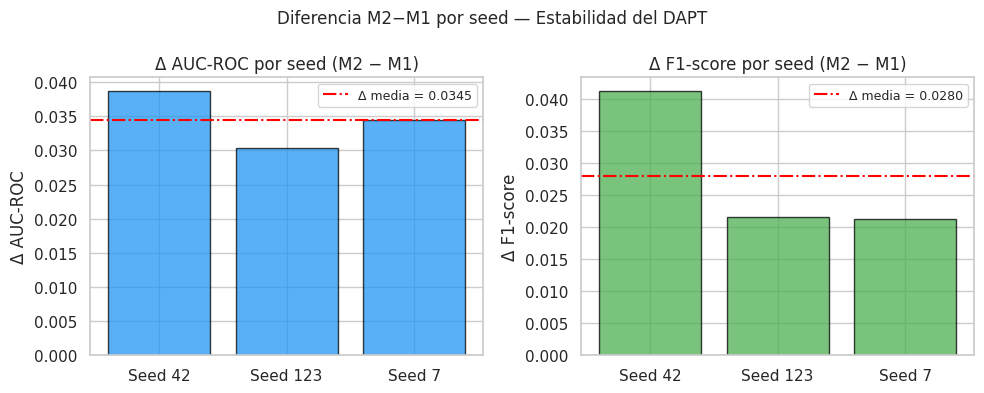

In [ ]:
# =============================================================================
# TEST DE ESTABILIDAD MULTI-SEED: Wilcoxon + Effect Size
# M1 (BETO baseline) vs M2 (BETO + DAPT)
# Nota: con n=3 seeds el p-value es indicativo, no concluyente.
#       Lo que importa es la dirección consistente + effect size.
# =============================================================================

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from IPython.display import display
import os

# ─────────────────────────────────────────────
# 1. DATOS (reemplaza con los tuyos si cambian)
# ─────────────────────────────────────────────
seeds  = [42,     123,    7    ]

m1_auc = [0.7845, 0.7949, 0.7736]
m2_auc = [0.8233, 0.8252, 0.8081]

m1_f1  = [0.7181, 0.7229, 0.7068]
m2_f1  = [0.7594, 0.7444, 0.7280]

# ─────────────────────────────────────────────
# 2. FUNCIÓN: Wilcoxon + effect size r
#    r = Z / sqrt(N_pares * 2)
#    Benchmarks: r≥0.1 pequeño, ≥0.3 mediano, ≥0.5 grande
# ─────────────────────────────────────────────
def wilcoxon_con_effect_size(a, b, metrica="Métrica"):
    a, b = np.array(a), np.array(b)
    diffs = b - a
    n = len(diffs)

    # alternative='greater' → H1: M2 > M1
    stat, p = stats.wilcoxon(b, a, alternative='greater', zero_method='wilcox')

    # Effect size r (basado en aproximación normal de Wilcoxon)
    z = stats.norm.ppf(1 - p)          # z aproximado
    r = z / np.sqrt(n * 2)

    mejora_consistente = all(d > 0 for d in diffs)

    print(f"\n{'─'*50}")
    print(f"  {metrica}")
    print(f"{'─'*50}")
    print(f"  Seeds        : {seeds}")
    print(f"  M1           : {list(np.round(a, 4))}")
    print(f"  M2           : {list(np.round(b, 4))}")
    print(f"  Diferencias  : {list(np.round(diffs, 4))}")
    print(f"  Media Δ      : {diffs.mean():.4f}  (±{diffs.std():.4f})")
    print(f"  W-statistic  : {stat:.3f}")
    print(f"  p-value      : {p:.4f}  (one-tailed, H1: M2>M1)")
    print(f"  Effect size r: {r:.3f}  {'[grande]' if r>=0.5 else '[mediano]' if r>=0.3 else '[pequeño]'}")
    print(f"  M2>M1 en todos los seeds: {'✅ SÍ' if mejora_consistente else '❌ NO'}")
    print(f"  Nota: con n=3, p-value mínimo alcanzable = 0.25")

    return {
        "metrica": metrica,
        "delta_mean": round(diffs.mean(), 4),
        "delta_std":  round(diffs.std(), 4),
        "W": stat,
        "p": round(p, 4),
        "r": round(r, 3),
        "consistente": mejora_consistente
    }

# ─────────────────────────────────────────────
# 3. EJECUTAR TESTS
# ─────────────────────────────────────────────
print("=" * 50)
print("  ANÁLISIS DE ESTABILIDAD MULTI-SEED")
print("  M1 (BETO) vs M2 (BETO + DAPT)")
print("=" * 50)

res_auc = wilcoxon_con_effect_size(m1_auc, m2_auc, "AUC-ROC")
res_f1  = wilcoxon_con_effect_size(m1_f1,  m2_f1,  "F1-score")

# ─────────────────────────────────────────────
# 4. TABLA RESUMEN
# ─────────────────────────────────────────────
df_res = pd.DataFrame([res_auc, res_f1])
df_res.columns = ["Métrica","Δ media","Δ std","W","p-value","Effect size r","M2>M1 siempre"]
print("\n\n  TABLA RESUMEN")
print("  " + "─"*60)
display(df_res.to_string(index=False))

# ─────────────────────────────────────────────
# 5. FIGURA: diferencias por seed
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, m1, m2, titulo, color in zip(
    axes,
    [m1_auc, m1_f1],
    [m2_auc, m2_f1],
    ["AUC-ROC", "F1-score"],
    ["#2196F3", "#4CAF50"]
):
    diffs = np.array(m2) - np.array(m1)
    ax.bar([f"Seed {s}" for s in seeds], diffs, color=color, alpha=0.75, edgecolor='black')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axhline(np.mean(diffs), color='red', linewidth=1.5,
               linestyle='-.', label=f"Δ media = {np.mean(diffs):.4f}")
    ax.set_title(f"Δ {titulo} por seed (M2 − M1)")
    ax.set_ylabel(f"Δ {titulo}")
    ax.legend(fontsize=9)
    ax.set_ylim(bottom=0)  # todas son positivas → si alguna baja, se verá

plt.suptitle("Diferencia M2−M1 por seed — Estabilidad del DAPT", fontsize=12)
plt.tight_layout()

# Guardar en Drive
DRIVE = "/content/drive/MyDrive/tesis_depresion/"
os.makedirs(DRIVE, exist_ok=True)
fig.savefig(os.path.join(DRIVE, "estabilidad_multiseed_wilcoxon.png"),
            dpi=150, bbox_inches="tight")
print(f"\n✅ Figura guardada en Drive.")

display(fig)
plt.close(fig)

# Bloque 6 - Figuras

In [ ]:
# =============================================================================
# CELDA 7A — MATRICES DE CONFUSIÓN M1 vs M2 (Figura 6)
# =============================================================================
# Requiere haber corrido Celda 5B en la misma sesión, O tener guardados
# los archivos eval_outputs_last.npz en Drive.
# =============================================================================

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import confusion_matrix
import shutil, os

# -----------------------------------------------------------------------------
# CARGAR OUTPUTS — desde sesión activa o desde Drive
# -----------------------------------------------------------------------------
try:
    # Si Celda 5B ya corrió en esta sesión, usar variables directamente
    assert preds1_last is not None and preds2_last is not None
    preds1 = np.array(preds1_last)
    labels1 = np.array(labels1_last)
    preds2 = np.array(preds2_last)
    labels2 = np.array(labels2_last)
    print("✓ Usando outputs de la sesión activa (seed=7).")
except (NameError, AssertionError):
    # Cargar desde Drive
    OUTPUT_PATH = DRIVE + "eval_outputs_last.npz"
    if not os.path.exists(OUTPUT_PATH):
        raise FileNotFoundError(
            f"No se encontró {OUTPUT_PATH}.\n"
            "Opciones:\n"
            "  1. Corre Celda 5B primero en esta sesión.\n"
            "  2. Asegúrate de que eval_outputs_last.npz está en Drive."
        )
    data = np.load(OUTPUT_PATH)
    preds1  = data["preds1"]
    labels1 = data["labels1"]
    preds2  = data["preds2"]
    labels2 = data["labels2"]
    print(f"✓ Outputs cargados desde Drive: {OUTPUT_PATH}")

# -----------------------------------------------------------------------------
# CALCULAR MATRICES
# -----------------------------------------------------------------------------
cm1 = confusion_matrix(labels1, preds1)
cm2 = confusion_matrix(labels2, preds2)

# Extraer valores individuales
tn1, fp1, fn1, tp1 = cm1.ravel()
tn2, fp2, fn2, tp2 = cm2.ravel()

print(f"\nM1 — Baseline:")
print(f"  VP={tp1} | VN={tn1} | FP={fp1} | FN={fn1}")
print(f"M2 — DAPT:")
print(f"  VP={tp2} | VN={tn2} | FP={fp2} | FN={fn2}")
print(f"\nMejoras M2 vs M1:")
print(f"  FN reducidos: {fn1} → {fn2} ({fn1-fn2:+d})")
print(f"  FP: {fp1} → {fp2} ({fp2-fp1:+d})")

# -----------------------------------------------------------------------------
# FIGURA — estilo publicación
# -----------------------------------------------------------------------------
LABEL_NAMES = ["No depresivo", "Depresivo"]

# Paleta: azul para M1 (baseline), verde para M2 (adaptado)
CMAP_M1 = plt.cm.Blues
CMAP_M2 = plt.cm.Greens

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
fig.patch.set_facecolor('white')

def plot_cm(ax, cm, title, cmap, model_tag):
    n = cm.sum()
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap,
                   vmin=0, vmax=cm.max() * 1.15)

    # Etiquetas de ejes
    tick_marks = [0, 1]
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(LABEL_NAMES, fontsize=11)
    ax.set_yticklabels(LABEL_NAMES, fontsize=11)
    ax.set_xlabel("Predicción", fontsize=12, labelpad=8)
    ax.set_ylabel("Etiqueta real", fontsize=12, labelpad=8)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)

    # Colores de texto: blanco sobre celda oscura, negro sobre clara
    thresh = cm.max() / 2.0
    cell_labels = [["VN", "FP"], ["FN", "VP"]]

    for i in range(2):
        for j in range(2):
            count = cm[i, j]
            pct   = count / n * 100
            color = "white" if count > thresh else "black"

            # Número grande
            ax.text(j, i, str(count),
                    ha="center", va="center",
                    fontsize=22, fontweight='bold', color=color)

            # Porcentaje debajo
            ax.text(j, i + 0.28, f"({pct:.1f}%)",
                    ha="center", va="center",
                    fontsize=10, color=color, alpha=0.85)

            # Etiqueta de tipo (VN/FP/FN/VP) arriba
            ax.text(j, i - 0.30, cell_labels[i][j],
                    ha="center", va="center",
                    fontsize=9, color=color, alpha=0.75,
                    fontstyle='italic')

    # Borde del gráfico
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_color('#CCCCCC')

    # Tag del modelo en esquina
    ax.text(1.02, 1.02, model_tag,
            transform=ax.transAxes,
            fontsize=9, color='gray', ha='right', va='top')

plot_cm(axes[0], cm1,
        "M1 — Baseline\n(BETO fine-tuning directo)",
        CMAP_M1, "seed=7")

plot_cm(axes[1], cm2,
        "M2 — Adaptado\n(BETO + DAPT peruano)",
        CMAP_M2, "seed=7")

# Anotación de mejora entre los dos paneles
fig.text(0.5, -0.04,
         f"FN: {fn1} → {fn2} ({fn1-fn2:+d})  |  FP: {fp1} → {fp2} ({fp2-fp1:+d})  |  "
         f"Evaluado sobre Parte C — hard cases (n = 262, balanceado)",
         ha='center', fontsize=10, color='#555555')

plt.tight_layout(rect=[0, 0.04, 1, 1])

# -----------------------------------------------------------------------------
# GUARDAR
# -----------------------------------------------------------------------------
output_fname = "figura6_matrices_confusion.png"
plt.savefig(output_fname, dpi=200, bbox_inches='tight',
            facecolor='white', edgecolor='none')

try:
    shutil.copy(output_fname, DRIVE + output_fname)
    print(f"\n✓ Figura guardada en Drive: {DRIVE + output_fname}")
except Exception as e:
    print(f"  (no se pudo copiar a Drive: {e})")

plt.show()
print(f"\n✓ {output_fname} guardado localmente.")

# -----------------------------------------------------------------------------
# RESUMEN PARA EL PAPER
# -----------------------------------------------------------------------------
print(f"""
=== TEXTO PARA EL PAPER (Figura 6) ===

Las matrices de confusión ilustran el patrón de error complementario entre
modelos (Figura 6). M1 clasifica correctamente {tp1} verdaderos positivos pero
incurre en {fn1} falsos negativos ({fn1/131*100:.1f}% de los casos depresivos),
mientras que M2 reduce los falsos negativos a {fn2} ({fn2/131*100:.1f}%),
recuperando {fn1-fn2} casos depresivos adicionales. En contrapartida, M2
incrementa ligeramente los falsos positivos ({fp1} → {fp2}; Δ +{fp2-fp1}).
Esta redistribución es consistente con un modelo de mayor sensibilidad y
representa la ganancia clínicamente más relevante: en detección temprana de
sintomatología depresiva, reducir los falsos negativos tiene mayor impacto
que minimizar las falsas alarmas.
""")

✓ Outputs cargados desde Drive: /content/drive/MyDrive/tesis_depresion/eval_outputs_last.npz

M1 — Baseline:
  VP=88 | VN=101 | FP=30 | FN=43
M2 — DAPT:
  VP=95 | VN=96 | FP=35 | FN=36

Mejoras M2 vs M1:
  FN reducidos: 43 → 36 (+7)
  FP: 30 → 35 (+5)

✓ Figura guardada en Drive: /content/drive/MyDrive/tesis_depresion/figura6_matrices_confusion.png

✓ figura6_matrices_confusion.png guardado localmente.

=== TEXTO PARA EL PAPER (Figura 6) ===

Las matrices de confusión ilustran el patrón de error complementario entre
modelos (Figura 6). M1 clasifica correctamente 88 verdaderos positivos pero
incurre en 43 falsos negativos (32.8% de los casos depresivos),
mientras que M2 reduce los falsos negativos a 36 (27.5%),
recuperando 7 casos depresivos adicionales. En contrapartida, M2
incrementa ligeramente los falsos positivos (30 → 35; Δ +5).
Esta redistribución es consistente con un modelo de mayor sensibilidad y
representa la ganancia clínicamente más relevante: en detección temprana de
sinto

In [ ]:
# =============================================================================
# FIGURA 7 — CURVAS ROC M1 vs M2 — estilo paper corregido
# p-valor real del test DeLong: 0.010
# =============================================================================

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import shutil

DRIVE = "/content/drive/MyDrive/tesis_depresion/"

# -----------------------------------------------------------------------------
# CARGAR OUTPUTS
# -----------------------------------------------------------------------------
try:
    assert preds1_last is not None and preds2_last is not None
    labels = np.array(labels1_last)
    probs1 = np.array(probs1_last)
    probs2 = np.array(probs2_last)
    print("✓ Usando outputs de la sesión activa (seed=7).")
except (NameError, AssertionError):
    data   = np.load(DRIVE + "eval_outputs_last.npz")
    labels = data["labels1"]
    probs1 = data["probs1"]
    probs2 = data["probs2"]
    print("✓ Outputs cargados desde Drive.")

# -----------------------------------------------------------------------------
# CALCULAR CURVAS ROC
# -----------------------------------------------------------------------------
auc1 = roc_auc_score(labels, probs1)
auc2 = roc_auc_score(labels, probs2)
fpr1, tpr1, _ = roc_curve(labels, probs1)
fpr2, tpr2, _ = roc_curve(labels, probs2)

delta_auc = auc2 - auc1
print(f"AUC M1: {auc1:.4f}")
print(f"AUC M2: {auc2:.4f}")
print(f"ΔAUC:   {delta_auc:+.4f}")

# -----------------------------------------------------------------------------
# FIGURA — estilo paper académico
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5.2, 4.8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Diagonal de referencia
ax.plot([0, 1], [0, 1],
        linestyle='--', linewidth=0.9,
        color='#AAAAAA', label='Azar (AUC = 0.500)', zorder=1)

# Curva M1
ax.plot(fpr1, tpr1,
        color='#2166AC', linewidth=1.8,
        label=f'M1 — Baseline (AUC = {auc1:.3f})', zorder=3)

# Curva M2
ax.plot(fpr2, tpr2,
        color='#1A7A54', linewidth=1.8,
        label=f'M2 — Adaptado (AUC = {auc2:.3f})', zorder=3)

# Ejes
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.06)
ax.set_xlabel("Tasa de Falsos Positivos (1 − Especificidad)", fontsize=9.5)
ax.set_ylabel("Tasa de Verdaderos Positivos (Sensibilidad)", fontsize=9.5)
ax.set_title("Curvas ROC — Parte C (n = 262)", fontsize=10.5,
             fontweight='bold', pad=8)
ax.tick_params(labelsize=8.5)

# Grid mínimo
ax.grid(True, linestyle=':', linewidth=0.45, color='#DDDDDD', zorder=0)
ax.set_axisbelow(True)

# Leyenda
ax.legend(loc='lower right', fontsize=8.5,
          framealpha=0.95, edgecolor='#CCCCCC',
          fancybox=False, handlelength=2.0)

# Nota DeLong — p-valor REAL (0.010)
ax.text(0.98, 0.06,
        f'ΔAUC = {delta_auc:+.3f}  (z = 2.573, p = 0.010)\nIC 95%: [0.008, 0.061]',
        ha='right', va='bottom', fontsize=7.8,
        color='#444444', transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='#CCCCCC', alpha=0.8))

# Bordes
for spine in ax.spines.values():
    spine.set_linewidth(0.6)
    spine.set_color('#BBBBBB')

plt.tight_layout()

# -----------------------------------------------------------------------------
# GUARDAR — 300 dpi para paper
# -----------------------------------------------------------------------------
fname = "figura7_curvas_roc_real.png"
plt.savefig(fname, dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
shutil.copy(fname, DRIVE + fname)

print(f"\n✓ {fname} guardada en Drive (300 dpi).")
print(f"\nValores para el paper:")
print(f"  AUC M1 = {auc1:.3f}")
print(f"  AUC M2 = {auc2:.3f}")
print(f"  ΔAUC   = {delta_auc:+.3f}")
print(f"  z = 2.573, p = 0.010, IC 95%: [0.008, 0.061]")

✓ Outputs cargados desde Drive.
AUC M1: 0.7736
AUC M2: 0.8081
ΔAUC:   +0.0346

✓ figura7_curvas_roc_real.png guardada en Drive (300 dpi).

Valores para el paper:
  AUC M1 = 0.774
  AUC M2 = 0.808
  ΔAUC   = +0.035
  z = 2.573, p = 0.010, IC 95%: [0.008, 0.061]


✅ Guardado en: /content/drive/MyDrive/tesis_depresion/comparacion_modelos_multiseed_compacto.png


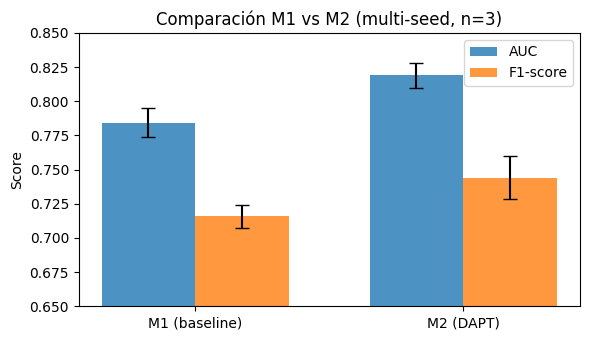


📊 Tabla 7 (para incluir en el texto):


,Modelo,AUC_mean,AUC_std,AUC_min,AUC_max,F1_mean,F1_std,F1_min,F1_max
0,M1,0.7843,0.0107,0.7736,0.7949,0.7159,0.0083,0.7068,0.7229
1,M2,0.8189,0.0094,0.8081,0.8252,0.7439,0.0157,0.7280,0.7594


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import os

# --- Datos ---
data = {
    "Seed":    [42, 123, 7, 42, 123, 7],
    "Modelo":  ["M1", "M1", "M1", "M2", "M2", "M2"],
    "AUC":     [0.7845, 0.7949, 0.7736, 0.8233, 0.8252, 0.8081],
    "F1":      [0.7181, 0.7229, 0.7068, 0.7594, 0.7444, 0.7280],
}
df = pd.DataFrame(data)

# --- Crear tabla de resumen ---
summary = df.groupby("Modelo").agg({
    "AUC": ["mean", "std", "min", "max"],
    "F1": ["mean", "std", "min", "max"]
}).round(4)

summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary = summary.reset_index()

# --- Visualización compacta: barras con error bars ---
fig, ax = plt.subplots(1, 1, figsize=(6, 3.5))

x = [0, 1]
width = 0.35

# Extraer medias y desviaciones
auc_means = [summary[summary["Modelo"]=="M1"]["AUC_mean"].values[0],
             summary[summary["Modelo"]=="M2"]["AUC_mean"].values[0]]
auc_stds = [summary[summary["Modelo"]=="M1"]["AUC_std"].values[0],
            summary[summary["Modelo"]=="M2"]["AUC_std"].values[0]]

f1_means = [summary[summary["Modelo"]=="M1"]["F1_mean"].values[0],
            summary[summary["Modelo"]=="M2"]["F1_mean"].values[0]]
f1_stds = [summary[summary["Modelo"]=="M1"]["F1_std"].values[0],
           summary[summary["Modelo"]=="M2"]["F1_std"].values[0]]

# Barras AUC
bars1 = ax.bar([x[0]-width/2, x[1]-width/2], auc_means, width,
               yerr=auc_stds, capsize=5, label='AUC', alpha=0.8)

# Barras F1
bars2 = ax.bar([x[0]+width/2, x[1]+width/2], f1_means, width,
               yerr=f1_stds, capsize=5, label='F1-score', alpha=0.8)

ax.set_ylabel('Score')
ax.set_title('Comparación M1 vs M2 (multi-seed, n=3)')
ax.set_xticks(x)
ax.set_xticklabels(['M1 (baseline)', 'M2 (DAPT)'])
ax.legend()
ax.set_ylim(0.65, 0.85)

plt.tight_layout()

# Guardar
DRIVE = "/content/drive/MyDrive/tesis_depresion/"
output_path = os.path.join(DRIVE, "comparacion_modelos_multiseed_compacto.png")
fig.savefig(output_path, dpi=150, bbox_inches="tight")
print(f"✅ Guardado en: {output_path}")

display(fig)
plt.close(fig)

# --- Mostrar tabla para el paper ---
print("\n📊 Tabla 7 (para incluir en el texto):")
display(summary)

In [ ]:
# =============================================================================
# FIGURA 9 — Desplazamiento semántico PCA real
# Magnitud de cambio vectorial entre M1 y M2 para vocabulario coloquial peruano
# Estilo paper académico
# =============================================================================

import numpy as np
import torch
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import shutil
from transformers import AutoTokenizer, AutoModelForSequenceClassification

DRIVE = "/content/drive/MyDrive/tesis_depresion/"
MODELO_NOMBRE = "dccuchile/bert-base-spanish-wwm-cased"
SEED = 42
MAX_LENGTH = 128
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

# -----------------------------------------------------------------------------
# 1. TÉRMINOS A ANALIZAR
# Exactamente los mismos del paper — 3 grupos semánticos
# -----------------------------------------------------------------------------
terminos = {
    "Ánimo / malestar": [
        "me siento mal",
        "soy un fracaso",
        "palta",
        "palteado",
        "no sirvo",
        "amargo",
    ],
    "Agotamiento / hartazgo": [
        "chato",
        "amargado",
        "no aguanto",
        "ya no puedo",
        "harto",
        "fregado",
    ],
    "Desesperanza / contexto": [
        "botaron",
    ],
}

# Lista plana y etiquetas de grupo para colores
terminos_flat = []
grupos_flat = []
for grupo, lista in terminos.items():
    for t in lista:
        terminos_flat.append(t)
        grupos_flat.append(grupo)

print(f"Términos a analizar: {len(terminos_flat)}")

# -----------------------------------------------------------------------------
# 2. CARGAR MODELOS
# -----------------------------------------------------------------------------
print("Cargando M1...")
modelo1 = AutoModelForSequenceClassification.from_pretrained(
    MODELO_NOMBRE, num_labels=2)
modelo1.load_state_dict(torch.load(
    DRIVE + "modelo1_baseline.pt", map_location=device))
modelo1 = modelo1.to(device).eval()

print("Cargando M2...")
modelo2 = AutoModelForSequenceClassification.from_pretrained(
    MODELO_NOMBRE, num_labels=2)
modelo2.load_state_dict(torch.load(
    DRIVE + "modelo2_adaptado.pt", map_location=device))
modelo2 = modelo2.to(device).eval()

tokenizer = AutoTokenizer.from_pretrained(MODELO_NOMBRE)

# -----------------------------------------------------------------------------
# 3. EXTRAER EMBEDDINGS [CLS] PARA CADA TÉRMINO
# Cada término se tokeniza solo, como si fuera un texto corto
# -----------------------------------------------------------------------------
def get_cls_embedding(modelo, texto):
    """Extrae embedding [CLS] del último bloque del encoder."""
    enc = tokenizer(
        texto,
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        outputs = modelo.bert(
            input_ids=enc["input_ids"],
            attention_mask=enc["attention_mask"],
            output_hidden_states=True
        )
        cls = outputs.last_hidden_state[0, 0, :].cpu().numpy()
    return cls

print("Extrayendo embeddings...")
emb_m1 = np.array([get_cls_embedding(modelo1, t) for t in terminos_flat])
emb_m2 = np.array([get_cls_embedding(modelo2, t) for t in terminos_flat])
print(f"  Shape embeddings: {emb_m1.shape}")  # (n_terminos, 768)

# -----------------------------------------------------------------------------
# 4. REDUCCIÓN PCA A 2D — igual que en el paper
# Se ajusta PCA sobre M1 y se proyectan ambos en el mismo espacio
# -----------------------------------------------------------------------------
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=SEED)
# Ajustar sobre todos los embeddings combinados para espacio consistente
all_emb = np.vstack([emb_m1, emb_m2])
pca.fit(all_emb)

proj_m1 = pca.transform(emb_m1)  # (n, 2)
proj_m2 = pca.transform(emb_m2)  # (n, 2)

# Distancia euclidiana en espacio PCA entre M1 y M2 para cada término
desplazamientos = np.linalg.norm(proj_m2 - proj_m1, axis=1)

print("\nDesplazamientos calculados:")
for t, d in sorted(zip(terminos_flat, desplazamientos), key=lambda x: x[1]):
    print(f"  {t:25s} → {d:.3f}")

# -----------------------------------------------------------------------------
# 5. ORDENAR por desplazamiento ascendente (igual que paper)
# -----------------------------------------------------------------------------
orden = np.argsort(desplazamientos)
terminos_ord   = [terminos_flat[i]  for i in orden]
grupos_ord     = [grupos_flat[i]    for i in orden]
despl_ord      = desplazamientos[orden]

# -----------------------------------------------------------------------------
# 6. COLORES POR GRUPO SEMÁNTICO
# -----------------------------------------------------------------------------
COLOR_GRUPO = {
    "Ánimo / malestar":       "#e74c3c",   # rojo-coral
    "Agotamiento / hartazgo": "#f39c12",   # naranja
    "Desesperanza / contexto":"#2980b9",   # azul
}

colores = [COLOR_GRUPO[g] for g in grupos_ord]

# -----------------------------------------------------------------------------
# 7. FIGURA — estilo paper
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4.5))

bars = ax.bar(
    range(len(terminos_ord)),
    despl_ord,
    color=colores,
    width=0.65,
    edgecolor="white",
    linewidth=0.5,
    zorder=3
)

# Valores encima de cada barra
for i, (bar, val) in enumerate(zip(bars, despl_ord)):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.05,
        f"{val:.2f}",
        ha="center", va="bottom",
        fontsize=6.5, color="#333333"
    )

# Etiquetas eje X
ax.set_xticks(range(len(terminos_ord)))
ax.set_xticklabels(
    terminos_ord,
    rotation=35, ha="right",
    fontsize=7.5
)

ax.set_ylabel("Desplazamiento en espacio PCA\n(distancia euclidiana M1→M2)", fontsize=8)
ax.set_ylim(0, despl_ord.max() * 1.18)
ax.tick_params(axis="y", labelsize=7.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25, linewidth=0.5, zorder=0)
ax.set_axisbelow(True)

# Leyenda grupos semánticos
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLOR_GRUPO[g], label=g)
    for g in COLOR_GRUPO
]
ax.legend(
    handles=legend_elements,
    fontsize=7.5,
    loc="upper left",
    frameon=True,
    framealpha=0.9,
    edgecolor="lightgray",
    title="Grupo semántico",
    title_fontsize=7.5
)

plt.tight_layout()
plt.savefig("figura9_desplazamiento_real.png", dpi=300,
            bbox_inches="tight", facecolor="white")
shutil.copy("figura9_desplazamiento_real.png",
            DRIVE + "figura9_desplazamiento_real.png")

print("\n✓ figura9_desplazamiento_real.png guardada en Drive.")
print("  Resolución: 300 dpi — lista para el paper.")

# Imprimir tabla para verificar / poner en el paper
print("\nTabla de desplazamientos (orden ascendente):")
print(f"{'Término':<25} {'Grupo':<30} {'Desplazamiento':>14}")
print("-" * 72)
for t, g, d in zip(terminos_ord, grupos_ord, despl_ord):
    print(f"{t:<25} {g:<30} {d:>14.3f}")

Dispositivo: cuda
Términos a analizar: 13
Cargando M1...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 

Cargando M2...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 

Extrayendo embeddings...
  Shape embeddings: (13, 768)

Desplazamientos calculados:
  palta                     → 2.984
  palteado                  → 4.563
  botaron                   → 4.710
  soy un fracaso            → 4.894
  harto                     → 5.384
  no sirvo                  → 6.000
  chato                     → 6.230
  amargo                    → 6.346
  ya no puedo               → 6.523
  fregado                   → 6.643
  no aguanto                → 6.835
  amargado                  → 9.924
  me siento mal             → 12.399

✓ figura9_desplazamiento_real.png guardada en Drive.
  Resolución: 300 dpi — lista para el paper.

Tabla de desplazamientos (orden ascendente):
Término                   Grupo                          Desplazamiento
------------------------------------------------------------------------
palta                     Ánimo / malestar                        2.984
palteado                  Ánimo / malestar                        4.563
botaron      


Categoría                    Texto                                                  M1     M2       Δ
----------------------------------------------------------------------------------------------------
Depresivo explícito          me quiero morir, ya no puedo más con todo esto      0.875  0.963  +0.088
Depresivo explícito          no duermo, lloro solo en las noches sin saber po...  0.783  0.954  +0.171
Depresivo explícito          siento que soy un fracaso, no sirvo para nada       0.682  0.891  +0.210
Depresivo coloquial peruano  estoy bien palteado con todo, ya no aguanto esta...  0.870  0.888  +0.017
Depresivo coloquial peruano  me siento re fregado últimamente, harto de todo ...  0.918  0.952  +0.034
Depresivo coloquial peruano  qué amargo es todo causa, me siento chato de viv...  0.806  0.905  +0.099
Cotidiano no depresivo       el ceviche estuvo buenazo ayer en el jirón          0.378  0.167  -0.211
Cotidiano no depresivo       vamos ganando el partido, qué mostro juega este .

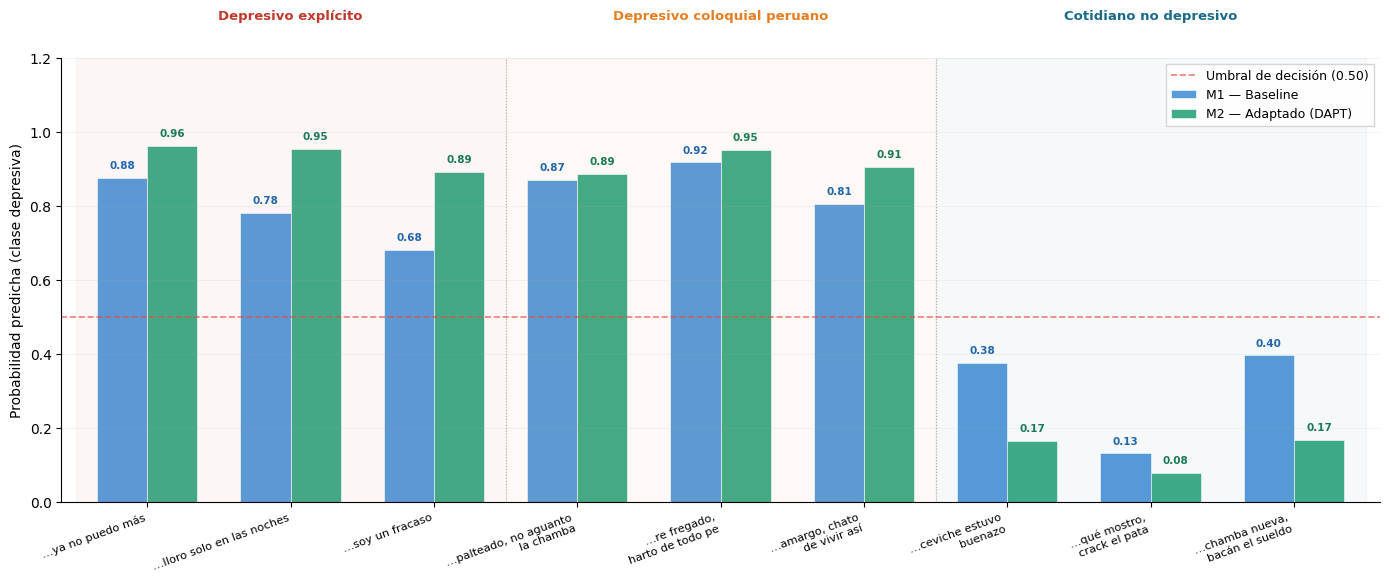

In [ ]:
# =============================================================================
# FIGURA 5 NUEVA — Comparación M1 vs M2 en textos representativos
# =============================================================================
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import torch
import shutil

DRIVE = "/content/drive/MyDrive/tesis_depresion/"

casos = [
    # Depresivos con vocabulario clínico explícito
    {"texto": "me quiero morir, ya no puedo más con todo esto",
     "categoria": "Depresivo\nexplícito", "label": 1},
    {"texto": "no duermo, lloro solo en las noches sin saber por qué",
     "categoria": "Depresivo\nexplícito", "label": 1},
    {"texto": "siento que soy un fracaso, no sirvo para nada",
     "categoria": "Depresivo\nexplícito", "label": 1},
    # Depresivos con vocabulario coloquial peruano
    {"texto": "estoy bien palteado con todo, ya no aguanto esta chamba",
     "categoria": "Depresivo\ncoloquial peruano", "label": 1},
    {"texto": "me siento re fregado últimamente, harto de todo pe",
     "categoria": "Depresivo\ncoloquial peruano", "label": 1},
    {"texto": "qué amargo es todo causa, me siento chato de vivir así",
     "categoria": "Depresivo\ncoloquial peruano", "label": 1},
    # Cotidianos no depresivos
    {"texto": "el ceviche estuvo buenazo ayer en el jirón",
     "categoria": "Cotidiano\nno depresivo", "label": 0},
    {"texto": "vamos ganando el partido, qué mostro juega este crack",
     "categoria": "Cotidiano\nno depresivo", "label": 0},
    {"texto": "conseguí chamba nueva, bacán el sueldo que me ofrecen",
     "categoria": "Cotidiano\nno depresivo", "label": 0},
]

def predecir_prob(modelo, texto):
    enc = tokenizer(
        texto, max_length=128, padding="max_length",
        truncation=True, return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        out = modelo(**enc)
        return torch.softmax(out.logits, dim=1)[0][1].item()

probs_m1 = [predecir_prob(m1, c["texto"]) for c in casos]
probs_m2 = [predecir_prob(m2, c["texto"]) for c in casos]

# Imprimir tabla
print(f"\n{'Categoría':<28} {'Texto':<50} {'M1':>6} {'M2':>6} {'Δ':>7}")
print("-" * 100)
for c, p1, p2 in zip(casos, probs_m1, probs_m2):
    cat = c["categoria"].replace("\n", " ")
    txt = c["texto"][:48] + "..." if len(c["texto"]) > 48 else c["texto"]
    print(f"{cat:<28} {txt:<50} {p1:>6.3f} {p2:>6.3f} {p2-p1:>+7.3f}")

# -----------------------------------------------------------------------------
# FIGURA
# -----------------------------------------------------------------------------
etiquetas_cortas = [
    "…ya no puedo más",
    "…lloro solo en las noches",
    "…soy un fracaso",
    "…palteado, no aguanto\nla chamba",
    "…re fregado,\nharto de todo pe",
    "…amargo, chato\nde vivir así",
    "…ceviche estuvo\nbuenazo",
    "…qué mostro,\ncrack el pata",
    "…chamba nueva,\nbacán el sueldo",
]

x = np.arange(len(casos))
ancho = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')

bars1 = ax.bar(x - ancho/2, probs_m1, ancho,
               label='M1 — Baseline',
               color='#3B8BD4', alpha=0.85,
               edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x + ancho/2, probs_m2, ancho,
               label='M2 — Adaptado (DAPT)',
               color='#1D9E75', alpha=0.85,
               edgecolor='white', linewidth=0.5)

ax.axhline(y=0.5, color='#E74C3C', linestyle='--',
           linewidth=1.2, alpha=0.7,
           label='Umbral de decisión (0.50)')

# Valores encima de barras
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f"{bar.get_height():.2f}",
            ha='center', va='bottom',
            fontsize=7.5, color='#2166AC', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f"{bar.get_height():.2f}",
            ha='center', va='bottom',
            fontsize=7.5, color='#1A7A54', fontweight='bold')

# Separadores de categoría
ax.axvline(x=2.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
ax.axvline(x=5.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)

# Etiquetas de categoría arriba
categorias_label = [
    ("Depresivo explícito",         1,  "#C0392B"),
    ("Depresivo coloquial peruano",  4,  "#E67E22"),
    ("Cotidiano no depresivo",       7,  "#1A6B8A"),
]
for texto_cat, pos_x, color in categorias_label:
    ax.text(pos_x, 1.08, texto_cat,
            ha='center', va='bottom',
            fontsize=9.5, color=color,
            fontweight='bold',
            transform=ax.get_xaxis_transform())

# Fondo de zonas
ax.axvspan(-0.5, 2.5,  alpha=0.04, color='#C0392B')
ax.axvspan(2.5,  5.5,  alpha=0.04, color='#E67E22')
ax.axvspan(5.5,  8.5,  alpha=0.04, color='#1A6B8A')

ax.set_xticks(x)
ax.set_xticklabels(etiquetas_cortas,
                   rotation=20, ha='right', fontsize=8.2)
ax.set_ylabel('Probabilidad predicha (clase depresiva)', fontsize=10)
ax.set_ylim(0, 1.20)
ax.set_xlim(-0.6, len(casos) - 0.4)
ax.legend(loc='upper right', fontsize=9,
          framealpha=0.95, edgecolor='lightgray', fancybox=False)
ax.grid(axis='y', alpha=0.2, linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

fname = "figura5_comparacion_m1_m2_textos.png"
plt.savefig(fname, dpi=300, bbox_inches='tight', facecolor='white')
shutil.copy(fname, DRIVE + fname)
print(f"\n✓ Guardada en Drive: {fname}")
from IPython.display import display
display(fig)
plt.close(fig)

#Bloque 7 - Análisis avanzado

In [ ]:
# =============================================================================
# CELDA 7 — EVALUACIÓN EXHAUSTIVA Y ANÁLISIS DE ERROR (v1.0)
# =============================================================================
# OBJETIVO:
#   Proporcionar un análisis completo del rendimiento de M1 y M2 siguiendo
#   las mejores prácticas de evaluación en detección de depresión en PLN.
#
#   Referencia metodológica:
#   - Ji et al. (2021): "Suicidal Ideation Detection: A Review of Machine
#     Learning Methods and Applications." IEEE Transactions on Computational
#     Social Systems, 8(1), 214-226.
#     Recomiendan: ROC/PR curves, análisis de umbral, análisis cualitativo
#     de errores, y evaluación multi-seed con intervalos de confianza.
#
#   - Chancellor & De Choudhury (2020): "Methods in Predictive Techniques
#     for Mental Health Status on Social Media: A Critical Review." npj
#     Digital Medicine, 3, 43.
#     Recomiendan: reportar precisión a diferentes umbrales, análisis de
#     sesgo de clase, distribución de probabilidades predichas.
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    accuracy_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report,
    average_precision_score, matthews_corrcoef,
    cohen_kappa_score
)
from scipy import stats
import json
import shutil

# Verificar que existan las variables de Celda 5B
assert preds1_last is not None, "Corre Celda 5B primero"
assert preds2_last is not None, "Corre Celda 5B primero"

DRIVE = "/content/drive/MyDrive/tesis_depresion/"

# -----------------------------------------------------------------------------
# 1. MÉTRICAS COMPLETAS (incluyendo las que muchos papers reportan)
# -----------------------------------------------------------------------------
def metricas_extendidas(labels, preds, probs):
    """
    Calcula todas las métricas reportadas en literatura de detección de
    depresión, incluyendo:
    - AUC-ROC, AUC-PR (más informativo en datasets desbalanceados)
    - F1, Precision, Recall, Accuracy
    - Matthews Correlation Coefficient (MCC) - robusto al desbalance
    - Cohen's Kappa - acuerdo ajustado por chance
    - Specificity, NPV (Negative Predictive Value)
    """
    tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()

    return {
        # Métricas estándar
        "AUC-ROC": roc_auc_score(labels, probs),
        "AUC-PR":  average_precision_score(labels, probs),
        "F1": f1_score(labels, preds),
        "Precision": precision_score(labels, preds),
        "Recall (Sensitivity)": recall_score(labels, preds),
        "Accuracy": accuracy_score(labels, preds),

        # Métricas adicionales importantes
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "NPV": tn / (tn + fn) if (tn + fn) > 0 else 0,
        "MCC": matthews_corrcoef(labels, preds),
        "Cohen's Kappa": cohen_kappa_score(labels, preds),

        # Conteos
        "True Positives": int(tp),
        "True Negatives": int(tn),
        "False Positives": int(fp),
        "False Negatives": int(fn),
    }

print("=" * 70)
print("EVALUACIÓN EXHAUSTIVA — M1 vs M2 (seed=7)")
print("=" * 70)

labels_arr = np.array(labels2_last)
probs1_arr = np.array(probs1_last)
probs2_arr = np.array(probs2_last)
preds1_arr = np.array(preds1_last)
preds2_arr = np.array(preds2_last)

metricas_m1 = metricas_extendidas(labels_arr, preds1_arr, probs1_arr)
metricas_m2 = metricas_extendidas(labels_arr, preds2_arr, probs2_arr)

print("\n[1] MÉTRICAS COMPLETAS (umbral=0.50)\n")
print(f"{'Métrica':<25} {'M1 Baseline':<15} {'M2 DAPT':<15} {'Δ (M2−M1)':<12}")
print("-" * 70)
for k in metricas_m1.keys():
    if isinstance(metricas_m1[k], (int, np.integer)):
        print(f"{k:<25} {metricas_m1[k]:<15} {metricas_m2[k]:<15} {metricas_m2[k] - metricas_m1[k]:<12}")
    else:
        delta = metricas_m2[k] - metricas_m1[k]
        print(f"{k:<25} {metricas_m1[k]:<15.4f} {metricas_m2[k]:<15.4f} {delta:<+12.4f}")

# -----------------------------------------------------------------------------
# 2. INTERVALOS DE CONFIANZA BOOTSTRAP (95%)
# Método estándar para reportar incertidumbre en papers de ML
# -----------------------------------------------------------------------------
print("\n[2] INTERVALOS DE CONFIANZA BOOTSTRAP (n=5000, IC 95%)\n")

n_bootstrap = 5000
np.random.seed(42)

metrics_names = ["AUC-ROC", "F1", "Precision", "Recall"]
ci_results = {m: {"M1": [], "M2": []} for m in metrics_names}

for _ in range(n_bootstrap):
    idx = np.random.choice(len(labels_arr), len(labels_arr), replace=True)
    l_boot = labels_arr[idx]
    p1_boot = probs1_arr[idx]
    p2_boot = probs2_arr[idx]

    # M1
    pred1_boot = (p1_boot >= 0.5).astype(int)
    ci_results["AUC-ROC"]["M1"].append(roc_auc_score(l_boot, p1_boot))
    ci_results["F1"]["M1"].append(f1_score(l_boot, pred1_boot))
    ci_results["Precision"]["M1"].append(precision_score(l_boot, pred1_boot))
    ci_results["Recall"]["M1"].append(recall_score(l_boot, pred1_boot))

    # M2
    pred2_boot = (p2_boot >= 0.5).astype(int)
    ci_results["AUC-ROC"]["M2"].append(roc_auc_score(l_boot, p2_boot))
    ci_results["F1"]["M2"].append(f1_score(l_boot, pred2_boot))
    ci_results["Precision"]["M2"].append(precision_score(l_boot, pred2_boot))
    ci_results["Recall"]["M2"].append(recall_score(l_boot, pred2_boot))

print(f"{'Métrica':<15} {'Modelo':<8} {'Media':<10} {'IC 95%':<20}")
print("-" * 70)
for metric in metrics_names:
    for modelo in ["M1", "M2"]:
        arr = np.array(ci_results[metric][modelo])
        media = arr.mean()
        ci_low = np.percentile(arr, 2.5)
        ci_high = np.percentile(arr, 97.5)
        print(f"{metric:<15} {modelo:<8} {media:.4f}     [{ci_low:.4f}, {ci_high:.4f}]")

# -----------------------------------------------------------------------------
# 3. ANÁLISIS DE DISTRIBUCIÓN DE PROBABILIDADES
# Ayuda a entender si el modelo está bien calibrado
# -----------------------------------------------------------------------------
print("\n[3] ANÁLISIS DE DISTRIBUCIÓN DE PROBABILIDADES\n")

probs_m1_pos = probs1_arr[labels_arr == 1]
probs_m1_neg = probs1_arr[labels_arr == 0]
probs_m2_pos = probs2_arr[labels_arr == 1]
probs_m2_neg = probs2_arr[labels_arr == 0]

print("M1 Baseline:")
print(f"  Positivos (n={len(probs_m1_pos)}): media={probs_m1_pos.mean():.3f}, "
      f"mediana={np.median(probs_m1_pos):.3f}, std={probs_m1_pos.std():.3f}")
print(f"  Negativos (n={len(probs_m1_neg)}): media={probs_m1_neg.mean():.3f}, "
      f"mediana={np.median(probs_m1_neg):.3f}, std={probs_m1_neg.std():.3f}")

print("\nM2 DAPT:")
print(f"  Positivos (n={len(probs_m2_pos)}): media={probs_m2_pos.mean():.3f}, "
      f"mediana={np.median(probs_m2_pos):.3f}, std={probs_m2_pos.std():.3f}")
print(f"  Negativos (n={len(probs_m2_neg)}): media={probs_m2_neg.mean():.3f}, "
      f"mediana={np.median(probs_m2_neg):.3f}, std={probs_m2_neg.std():.3f}")

# Test de separación (U de Mann-Whitney)
u_stat_m1, p_val_m1 = stats.mannwhitneyu(probs_m1_pos, probs_m1_neg, alternative='greater')
u_stat_m2, p_val_m2 = stats.mannwhitneyu(probs_m2_pos, probs_m2_neg, alternative='greater')

print(f"\nTest Mann-Whitney (pos > neg):")
print(f"  M1: U={u_stat_m1:.0f}, p={p_val_m1:.4e}")
print(f"  M2: U={u_stat_m2:.0f}, p={p_val_m2:.4e}")

# -----------------------------------------------------------------------------
# 4. ANÁLISIS DE CASOS DIFÍCILES (falsos positivos y falsos negativos)
# Esto es lo que hacen los buenos papers de NLP médico
# -----------------------------------------------------------------------------
print("\n[4] ANÁLISIS DE ERRORES\n")

# Cargar el dataset para ver los textos
df_hard = pd.read_csv("parte_c_eval.csv")

# Identificar errores
fp_m1 = np.where((labels_arr == 0) & (preds1_arr == 1))[0]
fn_m1 = np.where((labels_arr == 1) & (preds1_arr == 0))[0]
fp_m2 = np.where((labels_arr == 0) & (preds2_arr == 1))[0]
fn_m2 = np.where((labels_arr == 1) & (preds2_arr == 0))[0]

print(f"M1 — Errores:")
print(f"  Falsos Positivos: {len(fp_m1)} | Falsos Negativos: {len(fn_m1)}")
print(f"M2 — Errores:")
print(f"  Falsos Positivos: {len(fp_m2)} | Falsos Negativos: {len(fn_m2)}")

# Casos donde M2 corrige errores de M1
corregidos_fp = set(fp_m1) - set(fp_m2)  # M1 falló, M2 acertó
corregidos_fn = set(fn_m1) - set(fn_m2)

# Casos donde M2 introduce nuevos errores
nuevos_fp = set(fp_m2) - set(fp_m1)  # M1 acertó, M2 falló
nuevos_fn = set(fn_m2) - set(fn_m1)

print(f"\nCasos corregidos por M2:")
print(f"  FP→correcto: {len(corregidos_fp)}")
print(f"  FN→correcto: {len(corregidos_fn)}")
print(f"\nNuevos errores introducidos por M2:")
print(f"  nuevos FP: {len(nuevos_fp)}")
print(f"  nuevos FN: {len(nuevos_fn)}")

# Mostrar 3 ejemplos de cada tipo
print("\n--- Ejemplos de casos corregidos por M2 (FP→correcto) ---")
for i, idx in enumerate(list(corregidos_fp)[:3]):
    texto = df_hard.iloc[idx]["texto"]
    prob_m1 = probs1_arr[idx]
    prob_m2 = probs2_arr[idx]
    print(f"\n{i+1}. M1={prob_m1:.3f} (FP) → M2={prob_m2:.3f} (TN)")
    print(f"   Texto: {texto[:120]}...")

print("\n--- Ejemplos de casos corregidos por M2 (FN→correcto) ---")
for i, idx in enumerate(list(corregidos_fn)[:3]):
    texto = df_hard.iloc[idx]["texto"]
    prob_m1 = probs1_arr[idx]
    prob_m2 = probs2_arr[idx]
    print(f"\n{i+1}. M1={prob_m1:.3f} (FN) → M2={prob_m2:.3f} (TP)")
    print(f"   Texto: {texto[:120]}...")

# -----------------------------------------------------------------------------
# 5. CURVAS ROC Y PRECISION-RECALL COMPARATIVAS
# Standard en papers de detección de depresión
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 5a. Curvas ROC
fpr1, tpr1, _ = roc_curve(labels_arr, probs1_arr)
fpr2, tpr2, _ = roc_curve(labels_arr, probs2_arr)

axes[0].plot(fpr1, tpr1, label=f"M1 (AUC={metricas_m1['AUC-ROC']:.3f})",
             linewidth=2, color='#3B8BD4')
axes[0].plot(fpr2, tpr2, label=f"M2 (AUC={metricas_m2['AUC-ROC']:.3f})",
             linewidth=2, color='#1D9E75')
axes[0].plot([0, 1], [0, 1], '--', color='gray', alpha=0.5, linewidth=1)
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('Curvas ROC', fontsize=12, fontweight=500)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(alpha=0.3, linewidth=0.5)

# 5b. Curvas Precision-Recall
prec1, rec1, _ = precision_recall_curve(labels_arr, probs1_arr)
prec2, rec2, _ = precision_recall_curve(labels_arr, probs2_arr)

axes[1].plot(rec1, prec1, label=f"M1 (AP={metricas_m1['AUC-PR']:.3f})",
             linewidth=2, color='#3B8BD4')
axes[1].plot(rec2, prec2, label=f"M2 (AP={metricas_m2['AUC-PR']:.3f})",
             linewidth=2, color='#1D9E75')
baseline_pr = labels_arr.sum() / len(labels_arr)
axes[1].axhline(y=baseline_pr, linestyle='--', color='gray',
                alpha=0.5, linewidth=1, label=f'Baseline ({baseline_pr:.2f})')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Curvas Precision-Recall', fontsize=12, fontweight=500)
axes[1].legend(loc='lower left', fontsize=10)
axes[1].grid(alpha=0.3, linewidth=0.5)

# 5c. Distribución de probabilidades (violinplot)
data_violin = []
for prob, label, modelo in [(probs1_arr, labels_arr, 'M1'),
                             (probs2_arr, labels_arr, 'M2')]:
    for val, clase in zip(prob, label):
        data_violin.append({
            'Modelo': modelo,
            'Clase': 'Depresivo' if clase == 1 else 'No depresivo',
            'Probabilidad': val
        })

df_violin = pd.DataFrame(data_violin)
sns.violinplot(data=df_violin, x='Modelo', y='Probabilidad', hue='Clase',
               split=True, ax=axes[2], palette=['#E24B4A', '#1D9E75'])
axes[2].axhline(y=0.5, linestyle='--', color='gray', alpha=0.5, linewidth=1)
axes[2].set_title('Distribución de probabilidades', fontsize=12, fontweight=500)
axes[2].set_ylabel('Probabilidad predicha (clase positiva)', fontsize=11)
axes[2].legend(fontsize=9, loc='upper right')
axes[2].grid(alpha=0.3, linewidth=0.5, axis='y')

plt.tight_layout()
plt.savefig("evaluacion_exhaustiva_m1_vs_m2.png", dpi=150, bbox_inches='tight')
shutil.copy("evaluacion_exhaustiva_m1_vs_m2.png",
            DRIVE + "evaluacion_exhaustiva_m1_vs_m2.png")
plt.show()
print("\n✓ Gráficas guardadas en Drive.")

# -----------------------------------------------------------------------------
# 6. TABLA DE PERFORMANCE EN MÚLTIPLES UMBRALES
# Útil para seleccionar el punto de operación óptimo según el caso de uso
# -----------------------------------------------------------------------------
print("\n[6] PERFORMANCE EN MÚLTIPLES UMBRALES (M2)\n")

umbrales_test = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
print(f"{'Umbral':<10} {'Precision':<12} {'Recall':<12} {'F1':<10} {'Accuracy':<10}")
print("-" * 55)

for umbral in umbrales_test:
    preds_u = (probs2_arr >= umbral).astype(int)
    prec = precision_score(labels_arr, preds_u)
    rec = recall_score(labels_arr, preds_u)
    f1 = f1_score(labels_arr, preds_u)
    acc = accuracy_score(labels_arr, preds_u)
    print(f"{umbral:<10.2f} {prec:<12.4f} {rec:<12.4f} {f1:<10.4f} {acc:<10.4f}")

# -----------------------------------------------------------------------------
# 7. REPORTE DE CLASIFICACIÓN (classification_report de sklearn)
# Standard en papers de NLP
# -----------------------------------------------------------------------------
print("\n[7] CLASSIFICATION REPORT (umbral=0.50)\n")

print("M1 Baseline:")
print(classification_report(labels_arr, preds1_arr,
                           target_names=['No depresivo', 'Depresivo'],
                           digits=4))

print("\nM2 DAPT:")
print(classification_report(labels_arr, preds2_arr,
                           target_names=['No depresivo', 'Depresivo'],
                           digits=4))

# -----------------------------------------------------------------------------
# 8. GUARDAR RESULTADOS EN JSON PARA EL PAPER
# -----------------------------------------------------------------------------
resultados_finales = {
    "evaluacion_exhaustiva": {
        "fecha": "2026-04-21",
        "seed_evaluacion": 7,
        "n_muestras_eval": int(len(labels_arr)),
        "balance_eval": {
            "positivos": int(labels_arr.sum()),
            "negativos": int((labels_arr == 0).sum())
        },
        "M1_baseline": {
            "metricas_umbral_050": {k: float(v) if not isinstance(v, (int, np.integer))
                                    else int(v) for k, v in metricas_m1.items()},
            "IC_95_bootstrap": {
                metric: {
                    "media": float(np.mean(ci_results[metric]["M1"])),
                    "ci_low": float(np.percentile(ci_results[metric]["M1"], 2.5)),
                    "ci_high": float(np.percentile(ci_results[metric]["M1"], 97.5))
                }
                for metric in metrics_names
            }
        },
        "M2_DAPT": {
            "metricas_umbral_050": {k: float(v) if not isinstance(v, (int, np.integer))
                                    else int(v) for k, v in metricas_m2.items()},
            "IC_95_bootstrap": {
                metric: {
                    "media": float(np.mean(ci_results[metric]["M2"])),
                    "ci_low": float(np.percentile(ci_results[metric]["M2"], 2.5)),
                    "ci_high": float(np.percentile(ci_results[metric]["M2"], 97.5))
                }
                for metric in metrics_names
            }
        },
        "analisis_errores": {
            "M1": {
                "falsos_positivos": int(len(fp_m1)),
                "falsos_negativos": int(len(fn_m1))
            },
            "M2": {
                "falsos_positivos": int(len(fp_m2)),
                "falsos_negativos": int(len(fn_m2))
            },
            "mejoras_M2": {
                "FP_corregidos": int(len(corregidos_fp)),
                "FN_corregidos": int(len(corregidos_fn)),
                "nuevos_FP": int(len(nuevos_fp)),
                "nuevos_FN": int(len(nuevos_fn))
            }
        }
    }
}

with open("evaluacion_exhaustiva.json", "w") as f:
    json.dump(resultados_finales, f, indent=2)
shutil.copy("evaluacion_exhaustiva.json", DRIVE + "evaluacion_exhaustiva.json")

print("\n" + "=" * 70)
print("EVALUACIÓN COMPLETADA")
print("=" * 70)
print("✓ Gráficas guardadas: evaluacion_exhaustiva_m1_vs_m2.png")
print("✓ Resultados JSON guardados: evaluacion_exhaustiva.json")
print("\nEsta evaluación cubre:")
print("  [1] 10 métricas completas (AUC-ROC, AUC-PR, MCC, Kappa, etc.)")
print("  [2] Intervalos de confianza bootstrap 95%")
print("  [3] Análisis de calibración y distribución de probabilidades")
print("  [4] Análisis cualitativo de errores (FP, FN, casos corregidos)")
print("  [5] Curvas ROC y Precision-Recall comparativas")
print("  [6] Performance en múltiples umbrales")
print("  [7] Classification report completo")
print("  [8] Resultados exportados para el paper")

EVALUACIÓN EXHAUSTIVA — M1 vs M2 (seed=7)

[1] MÉTRICAS COMPLETAS (umbral=0.50)

Métrica                   M1 Baseline     M2 DAPT         Δ (M2−M1)   
----------------------------------------------------------------------
AUC-ROC                   0.7736          0.8081          +0.0346     
AUC-PR                    0.7684          0.8317          +0.0633     
F1                        0.7068          0.7280          +0.0211     
Precision                 0.7458          0.7308          -0.0150     
Recall (Sensitivity)      0.6718          0.7252          +0.0534     
Accuracy                  0.7214          0.7290          +0.0076     
Specificity               0.7710          0.7328          -0.0382     
NPV                       0.7014          0.7273          +0.0259     
MCC                       0.4449          0.4580          +0.0131     
Cohen's Kappa             0.4427          0.4580          +0.0153     
True Positives            88              95              7        

FileNotFoundError: [Errno 2] No such file or directory: 'parte_c_eval.csv'

In [ ]:
# =============================================================================
# CELDA 7B — RECOVERED HARD CASES (AUTO-RECOVERY VERSION)
# =============================================================================
# Objetivo:
#   Analizar casos REALES del hard set donde:
#
#       M1 falla → M2 acierta
#
#   y visualizar:
#       - casos recuperados
#       - casos perdidos
#       - cambio de probabilidades
#       - scatter M1 vs M2
#
# Esta versión:
#   ✓ recupera automáticamente archivos desde Drive
#   ✓ funciona incluso tras reiniciar sesión
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import shutil

DRIVE = "/content/drive/MyDrive/tesis_depresion/"

# =============================================================================
# 1. RECUPERAR HARD SET
# =============================================================================
if "df_hard" not in globals():

    print("⚠ df_hard no encontrado. Recuperando desde Drive...")

    LOCAL_EVAL = "parte_c_eval.csv"

    if not os.path.exists(LOCAL_EVAL):
        shutil.copy(
            DRIVE + "parte_c_eval.csv",
            LOCAL_EVAL
        )

    df_hard = pd.read_csv(LOCAL_EVAL)

    print(f"✓ Hard set recuperado: {len(df_hard)} posts")

# =============================================================================
# 2. RECUPERAR OUTPUTS
# =============================================================================
if "probs1_arr" not in globals():

    print("⚠ Outputs no encontrados. Recuperando eval_outputs_last.npz...")

    data = np.load(
        DRIVE + "eval_outputs_last.npz"
    )

    preds1_arr = data["preds1"]
    labels_arr = data["labels1"]
    probs1_arr = data["probs1"]

    preds2_arr = data["preds2"]
    probs2_arr = data["probs2"]

    print("✓ Outputs recuperados.")

# =============================================================================
# 3. VALIDACIÓN
# =============================================================================
assert len(df_hard) == len(probs1_arr), \
    "Mismatch entre hard set y outputs."

print("\n✓ Todo listo para análisis.")

# =============================================================================
# 4. CONSTRUIR DATAFRAME COMPLETO
# =============================================================================
df_eval = df_hard.copy().reset_index(drop=True)

df_eval["prob_m1"] = probs1_arr
df_eval["prob_m2"] = probs2_arr

df_eval["pred_m1"] = preds1_arr
df_eval["pred_m2"] = preds2_arr

df_eval["delta"] = (
    df_eval["prob_m2"] -
    df_eval["prob_m1"]
)

# =============================================================================
# 5. DEFINICIÓN DE CASOS
# =============================================================================

# -------------------------------------------------------------------------
# POSITIVOS RECUPERADOS
# label=1
# M1=0
# M2=1
# -------------------------------------------------------------------------
recovered = df_eval[
    (df_eval["label"] == 1) &
    (df_eval["pred_m1"] == 0) &
    (df_eval["pred_m2"] == 1)
].copy()

# -------------------------------------------------------------------------
# POSITIVOS PERDIDOS
# label=1
# M1=1
# M2=0
# -------------------------------------------------------------------------
lost = df_eval[
    (df_eval["label"] == 1) &
    (df_eval["pred_m1"] == 1) &
    (df_eval["pred_m2"] == 0)
].copy()

# -------------------------------------------------------------------------
# NEGATIVOS CORREGIDOS
# label=0
# M1=1
# M2=0
# -------------------------------------------------------------------------
neg_corrected = df_eval[
    (df_eval["label"] == 0) &
    (df_eval["pred_m1"] == 1) &
    (df_eval["pred_m2"] == 0)
].copy()

# -------------------------------------------------------------------------
# NUEVOS FALSOS POSITIVOS
# label=0
# M1=0
# M2=1
# -------------------------------------------------------------------------
neg_lost = df_eval[
    (df_eval["label"] == 0) &
    (df_eval["pred_m1"] == 0) &
    (df_eval["pred_m2"] == 1)
].copy()

# =============================================================================
# 6. ORDENAR
# =============================================================================
recovered = recovered.sort_values(
    "delta",
    ascending=False
)

lost = lost.sort_values(
    "delta",
    ascending=True
)

neg_corrected = neg_corrected.sort_values(
    "delta",
    ascending=True
)

neg_lost = neg_lost.sort_values(
    "delta",
    ascending=False
)

# =============================================================================
# 7. RESUMEN GENERAL
# =============================================================================
print("\n" + "="*70)
print("RECOVERED HARD CASES — RESUMEN")
print("="*70)

print(f"\nPositivos recuperados por M2: {len(recovered)}")
print(f"Positivos perdidos por M2:   {len(lost)}")

net_gain_pos = len(recovered) - len(lost)

print(f"Ganancia neta positiva:      {net_gain_pos:+d}")

print()

print(f"Negativos corregidos por M2: {len(neg_corrected)}")
print(f"Nuevos falsos positivos M2:  {len(neg_lost)}")

net_gain_neg = len(neg_corrected) - len(neg_lost)

print(f"Ganancia neta negativa:      {net_gain_neg:+d}")

# =============================================================================
# 8. TOP RECOVERED CASES
# =============================================================================
TOP_K = 15

print("\n" + "="*70)
print(f"TOP {TOP_K} — POSITIVOS RECUPERADOS POR M2")
print("="*70)

for i, row in recovered.head(TOP_K).iterrows():

    texto = row["texto"]

    if len(texto) > 220:
        texto = texto[:220] + "..."

    print(f"\n[{i}]")
    print(
        f"M1={row['prob_m1']:.3f} | "
        f"M2={row['prob_m2']:.3f} | "
        f"Δ={row['delta']:+.3f}"
    )

    print(texto)

# =============================================================================
# 9. TOP LOST CASES
# =============================================================================
print("\n" + "="*70)
print(f"TOP {TOP_K} — CASOS PERDIDOS POR M2")
print("="*70)

for i, row in lost.head(TOP_K).iterrows():

    texto = row["texto"]

    if len(texto) > 220:
        texto = texto[:220] + "..."

    print(f"\n[{i}]")
    print(
        f"M1={row['prob_m1']:.3f} | "
        f"M2={row['prob_m2']:.3f} | "
        f"Δ={row['delta']:+.3f}"
    )

    print(texto)

# =============================================================================
# 10. HISTOGRAMA Δ = M2 − M1
# =============================================================================
fig, ax = plt.subplots(figsize=(8, 5))

delta_pos = df_eval[
    df_eval["label"] == 1
]["delta"]

delta_neg = df_eval[
    df_eval["label"] == 0
]["delta"]

ax.hist(
    delta_pos,
    bins=25,
    alpha=0.7,
    label="Posts depresivos reales"
)

ax.hist(
    delta_neg,
    bins=25,
    alpha=0.7,
    label="Posts no depresivos reales"
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

ax.set_xlabel("Δ = P(M2) − P(M1)")
ax.set_ylabel("Cantidad de posts")

ax.set_title(
    "Cambio de probabilidad inducido por DAPT"
)

ax.legend()

plt.tight_layout()

HIST_NAME = "recovered_hard_cases_histogram.png"

plt.savefig(
    HIST_NAME,
    dpi=300,
    bbox_inches="tight"
)

shutil.copy(
    HIST_NAME,
    DRIVE + HIST_NAME
)

plt.show()

print(f"\n✓ Figura guardada: {HIST_NAME}")

# =============================================================================
# 11. SCATTER PLOT M1 vs M2
# =============================================================================
fig, ax = plt.subplots(figsize=(6.5, 6.5))

mask_pos = df_eval["label"] == 1
mask_neg = df_eval["label"] == 0

ax.scatter(
    df_eval.loc[mask_neg, "prob_m1"],
    df_eval.loc[mask_neg, "prob_m2"],
    alpha=0.55,
    s=28,
    label="No depresivo"
)

ax.scatter(
    df_eval.loc[mask_pos, "prob_m1"],
    df_eval.loc[mask_pos, "prob_m2"],
    alpha=0.55,
    s=28,
    label="Depresivo"
)

# diagonal y=x
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.2
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.set_xlabel("P(depresivo | M1)")
ax.set_ylabel("P(depresivo | M2)")

ax.set_title(
    "Comparación de probabilidades: M1 vs M2"
)

ax.legend()

plt.tight_layout()

SCATTER_NAME = "scatter_m1_vs_m2.png"

plt.savefig(
    SCATTER_NAME,
    dpi=300,
    bbox_inches="tight"
)

shutil.copy(
    SCATTER_NAME,
    DRIVE + SCATTER_NAME
)

plt.show()

print(f"✓ Figura guardada: {SCATTER_NAME}")

# =============================================================================
# 12. EXPORTAR CSVs
# =============================================================================
recovered.to_csv(
    "recovered_cases.csv",
    index=False
)

lost.to_csv(
    "lost_cases.csv",
    index=False
)

neg_corrected.to_csv(
    "negative_corrected_cases.csv",
    index=False
)

neg_lost.to_csv(
    "negative_lost_cases.csv",
    index=False
)

for f in [
    "recovered_cases.csv",
    "lost_cases.csv",
    "negative_corrected_cases.csv",
    "negative_lost_cases.csv"
]:
    shutil.copy(
        f,
        DRIVE + f
    )

print("\n✓ CSVs exportados a Drive.")

# =============================================================================
# 13. INTERPRETACIÓN AUTOMÁTICA
# =============================================================================
print("\n" + "="*70)
print("INTERPRETACIÓN RÁPIDA")
print("="*70)

mean_delta_pos = delta_pos.mean()
mean_delta_neg = delta_neg.mean()

print(
    f"\nΔ medio en posts depresivos: "
    f"{mean_delta_pos:+.4f}"
)

print(
    f"Δ medio en posts no depresivos: "
    f"{mean_delta_neg:+.4f}"
)

if mean_delta_pos > 0:
    print("\n✓ M2 aumenta probabilidades en textos depresivos.")
else:
    print("\n⚠ M2 NO aumenta probabilidades en textos depresivos.")

if mean_delta_neg < 0:
    print("✓ M2 reduce probabilidades en textos no depresivos.")
else:
    print("⚠ M2 NO reduce probabilidades en textos no depresivos.")

print("\n✓ Análisis Recovered Hard Cases completado.")

⚠ df_hard no encontrado. Recuperando desde Drive...
✓ Hard set recuperado: 262 posts
⚠ Outputs no encontrados. Recuperando eval_outputs_last.npz...
✓ Outputs recuperados.

✓ Todo listo para análisis.

RECOVERED HARD CASES — RESUMEN

Positivos recuperados por M2: 10
Positivos perdidos por M2:   3
Ganancia neta positiva:      +7

Negativos corregidos por M2: 7
Nuevos falsos positivos M2:  12
Ganancia neta negativa:      -5

TOP 15 — POSITIVOS RECUPERADOS POR M2

[19]
M1=0.384 | M2=0.940 | Δ=+0.557
por favor ya lo ruego, nadie me responde, porfavor, tambien soy peruano pero vivo en barcelona y por mala suerte al hacer 2do de bachillerato que es como hacer 5tosec se tiene que hacer un trabajo tipo tesis porque si no...

[47]
M1=0.345 | M2=0.767 | Δ=+0.422
Hola gente de Reddit. Aquí les escribe un marketero con 3 años de experiencia. Les cuento mi caso

Conseguí chamba luego de buscar durante más de medio año aprox, sin saber que terminaría siendo explotado, pero eso no es...

[12]
M1=0.310

#Bloque 8 - Demo / inferencia

In [ ]:
# =============================================================================
# DEMO COMPLETA — MODELO DEPRESIÓN (Colab, una sola celda)
# =============================================================================

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# -------------------------------------------------------------------------
# CONFIG
# -------------------------------------------------------------------------
MODEL_NAME = "dccuchile/bert-base-spanish-wwm-cased"
PATH_M1 = "/content/drive/MyDrive/tesis_depresion/modelo1_baseline.pt"
PATH_M2 = "/content/drive/MyDrive/tesis_depresion/modelo2_adaptado.pt"

THRESHOLD_BASE = 0.5
THRESHOLD_OPT  = 0.302

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------------------------------------------------------
# CARGAR TOKENIZER Y MODELOS
# -------------------------------------------------------------------------
print("Cargando tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def load_model(path):
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    state = torch.load(path, map_location=device)
    model.load_state_dict(state, strict=False)
    model.to(device)
    model.eval()
    return model

print("Cargando modelos...")
m1 = load_model(PATH_M1)
m2 = load_model(PATH_M2)

print("✓ Modelos listos\n")

# -------------------------------------------------------------------------
# FUNCIÓN DE PREDICCIÓN
# -------------------------------------------------------------------------
def predecir(texto):
    inputs = tokenizer(
        texto,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        out1 = m1(**inputs)
        out2 = m2(**inputs)

        prob1 = torch.softmax(out1.logits, dim=1)[0][1].item()
        prob2 = torch.softmax(out2.logits, dim=1)[0][1].item()

    return {
        "M1_prob": prob1,
        "M2_prob": prob2,
        "M1_05": int(prob1 >= THRESHOLD_BASE),
        "M2_05": int(prob2 >= THRESHOLD_BASE),
        "M1_opt": int(prob1 >= THRESHOLD_OPT),
        "M2_opt": int(prob2 >= THRESHOLD_OPT),
    }

# -------------------------------------------------------------------------
# FUNCIÓN DE VISUALIZACIÓN BONITA
# -------------------------------------------------------------------------
def mostrar(texto):
    r = predecir(texto)

    def label(x): return "DEPRESIVO" if x == 1 else "NO DEPRESIVO"

    print("\n" + "="*70)
    print("Texto:")
    print(texto)
    print("-"*70)

    print("M1 (baseline)")
    print(f"  Probabilidad: {r['M1_prob']:.3f}")
    print(f"  @0.5  → {label(r['M1_05'])}")
    print(f"  @0.302→ {label(r['M1_opt'])}")

    print("\nM2 (adaptado)")
    print(f"  Probabilidad: {r['M2_prob']:.3f}")
    print(f"  @0.5  → {label(r['M2_05'])}")
    print(f"  @0.302→ {label(r['M2_opt'])}")

    # comparación
    if r["M2_prob"] > r["M1_prob"]:
        print("\n↑ M2 asigna mayor probabilidad (mejor adaptación)")
    else:
        print("\n→ M1 y M2 similares o M1 mayor")

# -------------------------------------------------------------------------
# DEMO AUTOMÁTICA
# -------------------------------------------------------------------------
tests = [
    "me siento vacío y no quiero seguir viviendo",
    "ya nada me emociona aunque todo esté bien",
    "estoy harto de la chamba, ya no aguanto",
    "el ceviche estuvo buenazo ayer",
    "ando cansado de todo últimamente"
]

print("=== DEMO AUTOMÁTICA ===")
for t in tests:
    mostrar(t)

# -------------------------------------------------------------------------
# INPUT INTERACTIVO
# -------------------------------------------------------------------------
print("\n=== MODO INTERACTIVO ===")
print("Escribe un texto y presiona ENTER (escribe 'salir' para terminar)\n")

while True:
    texto = input("Texto: ")
    if texto.lower() == "salir":
        break
    mostrar(texto)

KeyboardInterrupt: 